# Adquisicion de lo datos

In [1]:
import requests
import json

# Lista de monedas objetivo
mis_tokens = {
    "kava", "concordium", "harmony", "celer", "nolus",
    "oasys", "stargaze", "hydration", "bitgert", "kadena"
}

# 1. Obtener todas las monedas de CoinGecko
url = "https://api.coingecko.com/api/v3/coins/list"
response = requests.get(url)
all_coins = response.json()

# 2. Filtrar solo las que te interesan
mis_criptos = []
for coin in all_coins:
    if coin["id"] in mis_tokens:
        mis_criptos.append({
            "gecko_id": coin["id"],
            "name": coin["name"],
            "token": coin["symbol"]
        })

# 3. Eliminar duplicados (por si acaso)
unique = {c["gecko_id"]: c for c in mis_criptos}.values()

# 4. Guardar en JSON
with open("criptomonedas.json", "w") as f:
    json.dump(list(unique), f, indent=4)

print("✔️ criptomonedas.json generado correctamente.")


✔️ criptomonedas.json generado correctamente.


In [2]:
import json
import requests
from time import sleep

# 1. Cargar monedas desde el JSON generado en 1stphase
with open("criptomonedas.json", "r") as f:
    tokens = json.load(f)

# 2. Obtener chains de DeFiLlama
llama_url = "https://api.llama.fi/v2/chains"
chains = requests.get(llama_url).json()

# Convertimos los nombres a minúsculas para comparar fácilmente
chain_names = {chain["name"].lower(): chain["name"] for chain in chains}

# 3. Intentar encontrar match por nombre entre CoinGecko y DeFiLlama
tvl_histories = {}

for token in tokens:
    name = token["name"].lower()

    # Buscar el nombre en la lista de chains de DefiLlama
    match = next((llama_name for llama_name in chain_names if llama_name in name), None)
    if not match:
        print(f"No TVL encontrado para {token['name']}")
        continue

    # Llamar al endpoint de historial de TVL
    print(f"Obteniendo TVL para {chain_names[match]}...")
    tvl_url = f"https://api.llama.fi/v2/historicalChainTvl/{chain_names[match]}"
    response = requests.get(tvl_url)

    if response.status_code == 200:
        tvl_histories[token["token"]] = {
            "chain_name": chain_names[match],
            "tvl_history": response.json()
        }
    else:
        print(f"❌ Error con {chain_names[match]}")

    sleep(1.2)  # Para evitar rate limit

# 4. Guardar todo en un JSON
with open("historial_tvl_criptomonedas.json", "w") as f:
    json.dump(tvl_histories, f, indent=4)

print("✔️ historial_tvl_criptomonedas.json guardado con éxito.")


Obteniendo TVL para Concordium...
Obteniendo TVL para Harmony...


KeyboardInterrupt: 

In [ ]:
import json
import requests
import pandas as pd
from datetime import datetime
from time import sleep

# Nuevo rango de fechas válido (CoinGecko solo permite últimos 365 días)
from_date = int(datetime(2024, 6, 1).timestamp())
to_date = int(datetime(2025, 5, 31).timestamp())

# Headers para evitar 401
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Cargar archivos previos
with open("criptomonedas.json", "r") as f:
    tokens = json.load(f)

with open("historial_tvl_criptomonedas.json", "r") as f:
    tvl_data = json.load(f)

# Convertidor de timestamp a fecha YYYY-MM-DD
def to_date_str(ts):
    return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d")

rows = []

for token in tokens:
    gecko_id = token["gecko_id"].lower().strip()
    name = token["name"]
    symbol = token["token"]

    url = f"https://api.coingecko.com/api/v3/coins/{gecko_id}/market_chart/range"
    params = {
        "vs_currency": "usd",
        "from": from_date,
        "to": to_date
    }

    print(f"Descargando data de {name}...")
    r = requests.get(url, params=params, headers=headers)
    if r.status_code != 200:
        print(f"❌ Falló {name} ({gecko_id}): {r.status_code}")
        continue

    data = r.json()
    prices = data.get("prices", [])
    market_caps = data.get("market_caps", [])
    volumes = data.get("total_volumes", [])

    # Verificar que tenga suficiente data
    if not prices or not market_caps:
        print(f"⚠️ Sin datos válidos para {name}")
        continue

    df = pd.DataFrame({
        "date": [to_date_str(p[0] // 1000) for p in prices],
        "price": [p[1] for p in prices],
        "market_cap": [mc[1] for mc in market_caps],
        "volume": [v[1] for v in volumes],
    })

    df["token"] = symbol
    df["name"] = name

    # Merge con TVL si existe
    tvl_history = tvl_data.get(symbol, {}).get("tvl_history", [])
    tvl_df = pd.DataFrame(tvl_history)
    if not tvl_df.empty:
        tvl_df["date"] = tvl_df["date"].apply(to_date_str)
        df = df.merge(tvl_df, on="date", how="left")
        df.rename(columns={"tvl": "tvl_usd"}, inplace=True)
    else:
        df["tvl_usd"] = None

    # Métricas derivadas
    df["volume_to_marketcap"] = df["volume"] / df["market_cap"]
    df["price_change_%"] = df["price"].pct_change() * 100
    df["market_cap_trend"] = df["market_cap"].pct_change() * 100
    df["tvl_trend"] = df["tvl_usd"].pct_change() * 100

    # Narrativa
    narrativa = token.get("narrative", "Desconocido")
    df["narrative"] = narrativa

    rows.append(df)
    sleep(1.1)  # evitar rate limit

# Guardar CSV
if rows:
    final_df = pd.concat(rows)
    final_df.dropna(subset=["price", "market_cap"], inplace=True)
    final_df.to_csv("dataset_criptos_2024_2025.csv", index=False)
    print("✅ dataset_criptos_2024_2025.csv guardado con éxito.")
else:
    print("❌ No se pudo generar el dataset. Verifica los gecko_id y la conexión.")


Descargando data de Concordium...


C:\Users\rosar\AppData\Local\Temp\ipykernel_14604\521250748.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d")
C:\Users\rosar\AppData\Local\Temp\ipykernel_14604\521250748.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d")


Descargando data de Harmony...


C:\Users\rosar\AppData\Local\Temp\ipykernel_14604\521250748.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d")
C:\Users\rosar\AppData\Local\Temp\ipykernel_14604\521250748.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d")


Descargando data de Kadena...


...

Descargando data de Kava...


C:\Users\rosar\AppData\Local\Temp\ipykernel_14604\521250748.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d")
C:\Users\rosar\AppData\Local\Temp\ipykernel_14604\521250748.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d")


Descargando data de Nolus...


C:\Users\rosar\AppData\Local\Temp\ipykernel_14604\521250748.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d")
C:\Users\rosar\AppData\Local\Temp\ipykernel_14604\521250748.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  return datetime.utcfromtimestamp(ts).strftime("%Y-%m-%d")


Descargando data de Oasys...
❌ Falló Oasys (oasys): 429
Descargando data de Stargaze...
❌ Falló Stargaze (stargaze): 429
✅ dataset_criptos_2024_2025.csv guardado con éxito.


# EDA inicial (data cruda)

## Exploración Inicial

In [9]:
import pandas as pd
# Cargar datos 
data =  pd.read_csv(r"C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\criptodataset.csv")

In [10]:
eda_data = data.copy()

In [11]:
eda_data.head()

,date,price,market_cap,volume,token,name,tvl_usd,volume_to_marketcap,price_change_%,market_cap_trend,tvl_trend,narrative
0,2024-06-01,0.021743,2.677851e+08,4.748500e+06,one,Harmony,2870121,0.017732,NaN,NaN,NaN,Desconocido
1,2024-06-02,0.021809,2.682872e+08,3.105342e+06,one,Harmony,2927085,0.011575,0.303395,0.187511,1.984725,Desconocido
2,2024-06-03,0.021625,2.661746e+08,6.740671e+06,one,Harmony,2832820,0.025324,-0.843260,-0.787463,-3.220439,Desconocido
3,2024-06-04,0.022032,2.707636e+08,6.316662e+06,one,Harmony,2929770,0.023329,1.885679,1.724051,3.422385,Desconocido
4,2024-06-05,0.022940,2.822307e+08,6.750956e+06,one,Harmony,2433359,0.023920,4.121088,4.235119,-16.943685,Desconocido


In [12]:
eda_data.describe()

,price,market_cap,volume,tvl_usd,volume_to_marketcap,price_change_%,market_cap_trend,tvl_trend
count,1740.000000,1.740000e+03,1.740000e+03,1.740000e+03,1740.000000,1735.000000,1735.000000,1735.000000
mean,0.224612,1.777126e+08,1.127639e+07,3.309387e+07,0.048381,-0.161313,-0.103440,0.339615
std,0.295149,1.808609e+08,2.096859e+07,6.502968e+07,0.057917,5.096132,5.098647,11.335973
min,0.000983,2.635667e+06,1.011485e+03,7.246400e+04,0.000199,-20.419520,-20.265189,-68.589293
25%,0.010654,9.298688e+06,1.233864e+05,3.205822e+05,0.010254,-2.721573,-2.741799,-2.811987
50%,0.016684,1.505689e+08,6.025160e+06,1.133220e+06,0.035491,-0.253257,-0.156880,0.000000
75%,0.453352,2.947722e+08,1.344001e+07,2.455542e+06,0.063734,2.098528,2.180865,2.352405
max,1.853151,7.748413e+08,3.250321e+08,2.217892e+08,0.843553,44.344404,44.223039,223.317782


In [13]:
eda_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 1740 non-null   object 
 1   price                1740 non-null   float64
 2   market_cap           1740 non-null   float64
 3   volume               1740 non-null   float64
 4   token                1740 non-null   object 
 5   name                 1740 non-null   object 
 6   tvl_usd              1740 non-null   int64  
 7   volume_to_marketcap  1740 non-null   float64
 8   price_change_%       1735 non-null   float64
 9   market_cap_trend     1735 non-null   float64
 10  tvl_trend            1735 non-null   float64
 11  narrative            1740 non-null   object 
dtypes: float64(7), int64(1), object(4)
memory usage: 163.2+ KB


## Verificacion de valores nulos y duplicados

In [14]:

print(eda_data.isnull().sum())

date                   0
price                  0
market_cap             0
volume                 0
token                  0
name                   0
tvl_usd                0
volume_to_marketcap    0
price_change_%         5
market_cap_trend       5
tvl_trend              5
narrative              0
dtype: int64


In [15]:
'''
Los nulos de son los primeros registros de cada token por lo que los vamos a dropear 
'''

# Eliminar esas 5 filas nulas (no afecta la calidad del dataset)
# eda_data = eda_data.dropna(subset=["price_change_%", "market_cap_trend", "tvl_trend"])
eda_data = eda_data.fillna(0)


In [16]:
print(eda_data.isnull().sum())

date                   0
price                  0
market_cap             0
volume                 0
token                  0
name                   0
tvl_usd                0
volume_to_marketcap    0
price_change_%         0
market_cap_trend       0
tvl_trend              0
narrative              0
dtype: int64


In [17]:
print(eda_data.duplicated().sum())

0


In [18]:
'''
Borramos la columna narrative ya que no aporta nada al modelo
todos los valores son "desconocido"
'''

eda_data.drop(columns=["narrative"],inplace=True)

In [19]:
eda_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1740 entries, 0 to 1739
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 1740 non-null   object 
 1   price                1740 non-null   float64
 2   market_cap           1740 non-null   float64
 3   volume               1740 non-null   float64
 4   token                1740 non-null   object 
 5   name                 1740 non-null   object 
 6   tvl_usd              1740 non-null   int64  
 7   volume_to_marketcap  1740 non-null   float64
 8   price_change_%       1740 non-null   float64
 9   market_cap_trend     1740 non-null   float64
 10  tvl_trend            1740 non-null   float64
dtypes: float64(7), int64(1), object(3)
memory usage: 149.7+ KB


## Distribucíon de variables numéricas por cada token

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
numeric_columns = eda_data.select_dtypes(include='number').columns

In [22]:
from scipy.stats import skew, kurtosis, shapiro

In [23]:
def plot_numeric_distributions(data, numeric_cols):  
    cols_per_row = 2
    n = len(numeric_cols)
    rows = -(-n // cols_per_row)  

    plt.figure(figsize=(cols_per_row * 7, rows * 4))

    for idx, col in enumerate(numeric_cols, 1):
        sk = skew(data[col].dropna())
        kt = kurtosis(data[col].dropna())
        _, p = shapiro(data[col].dropna())

        plt.subplot(rows, cols_per_row*2, idx*2-1)
        sns.histplot(data[col], kde=True, bins=20, color="skyblue")
        plt.title(f"{col}\nSkew: {sk:.2f}, Kurt: {kt:.2f}, p={p:.2g}")

        plt.subplot(rows, cols_per_row*2, idx*2)
        sns.boxplot(x=data[col], color="lightcoral")
        plt.title(f"{col} - Boxplot")

    plt.tight_layout()
    plt.show()

### Distribución de variables numéricas para Harmony


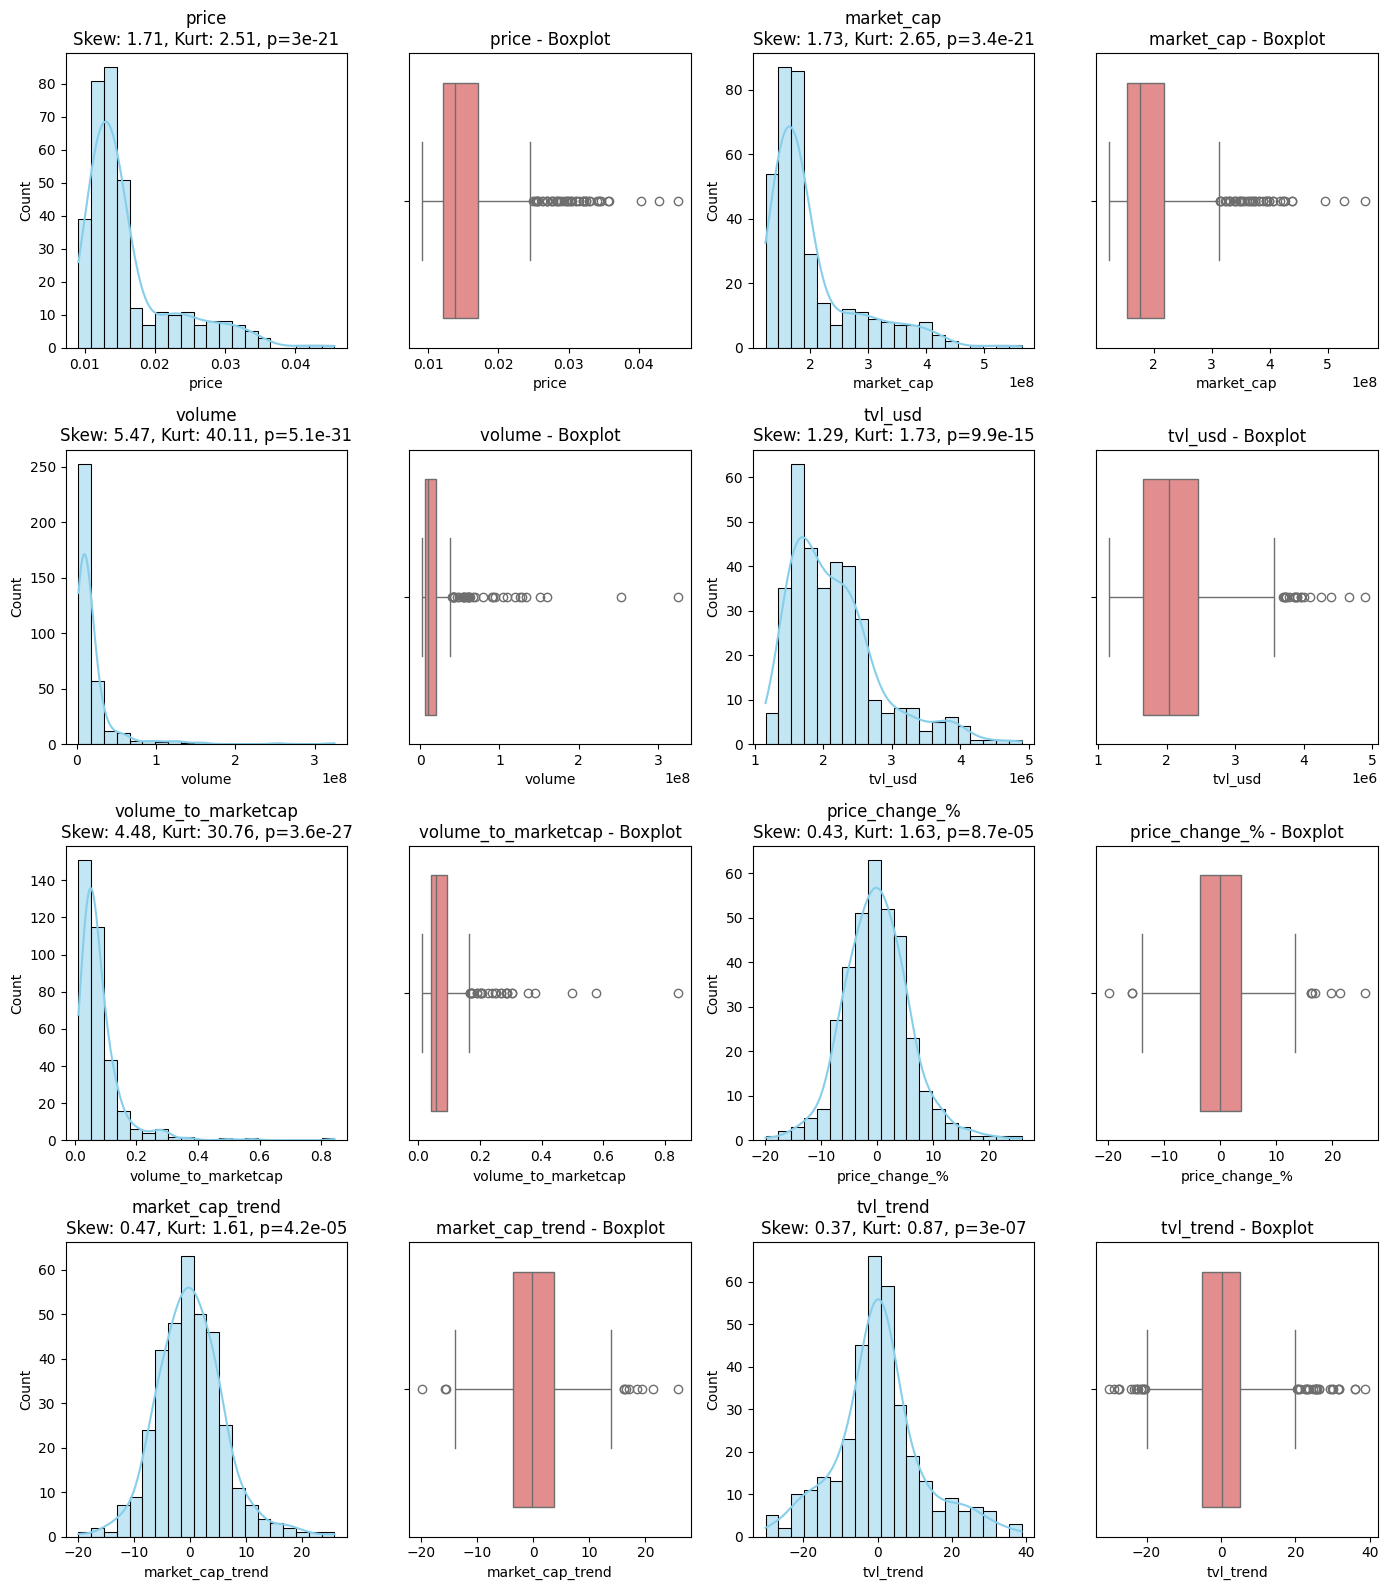

### Distribución de variables numéricas para Kadena


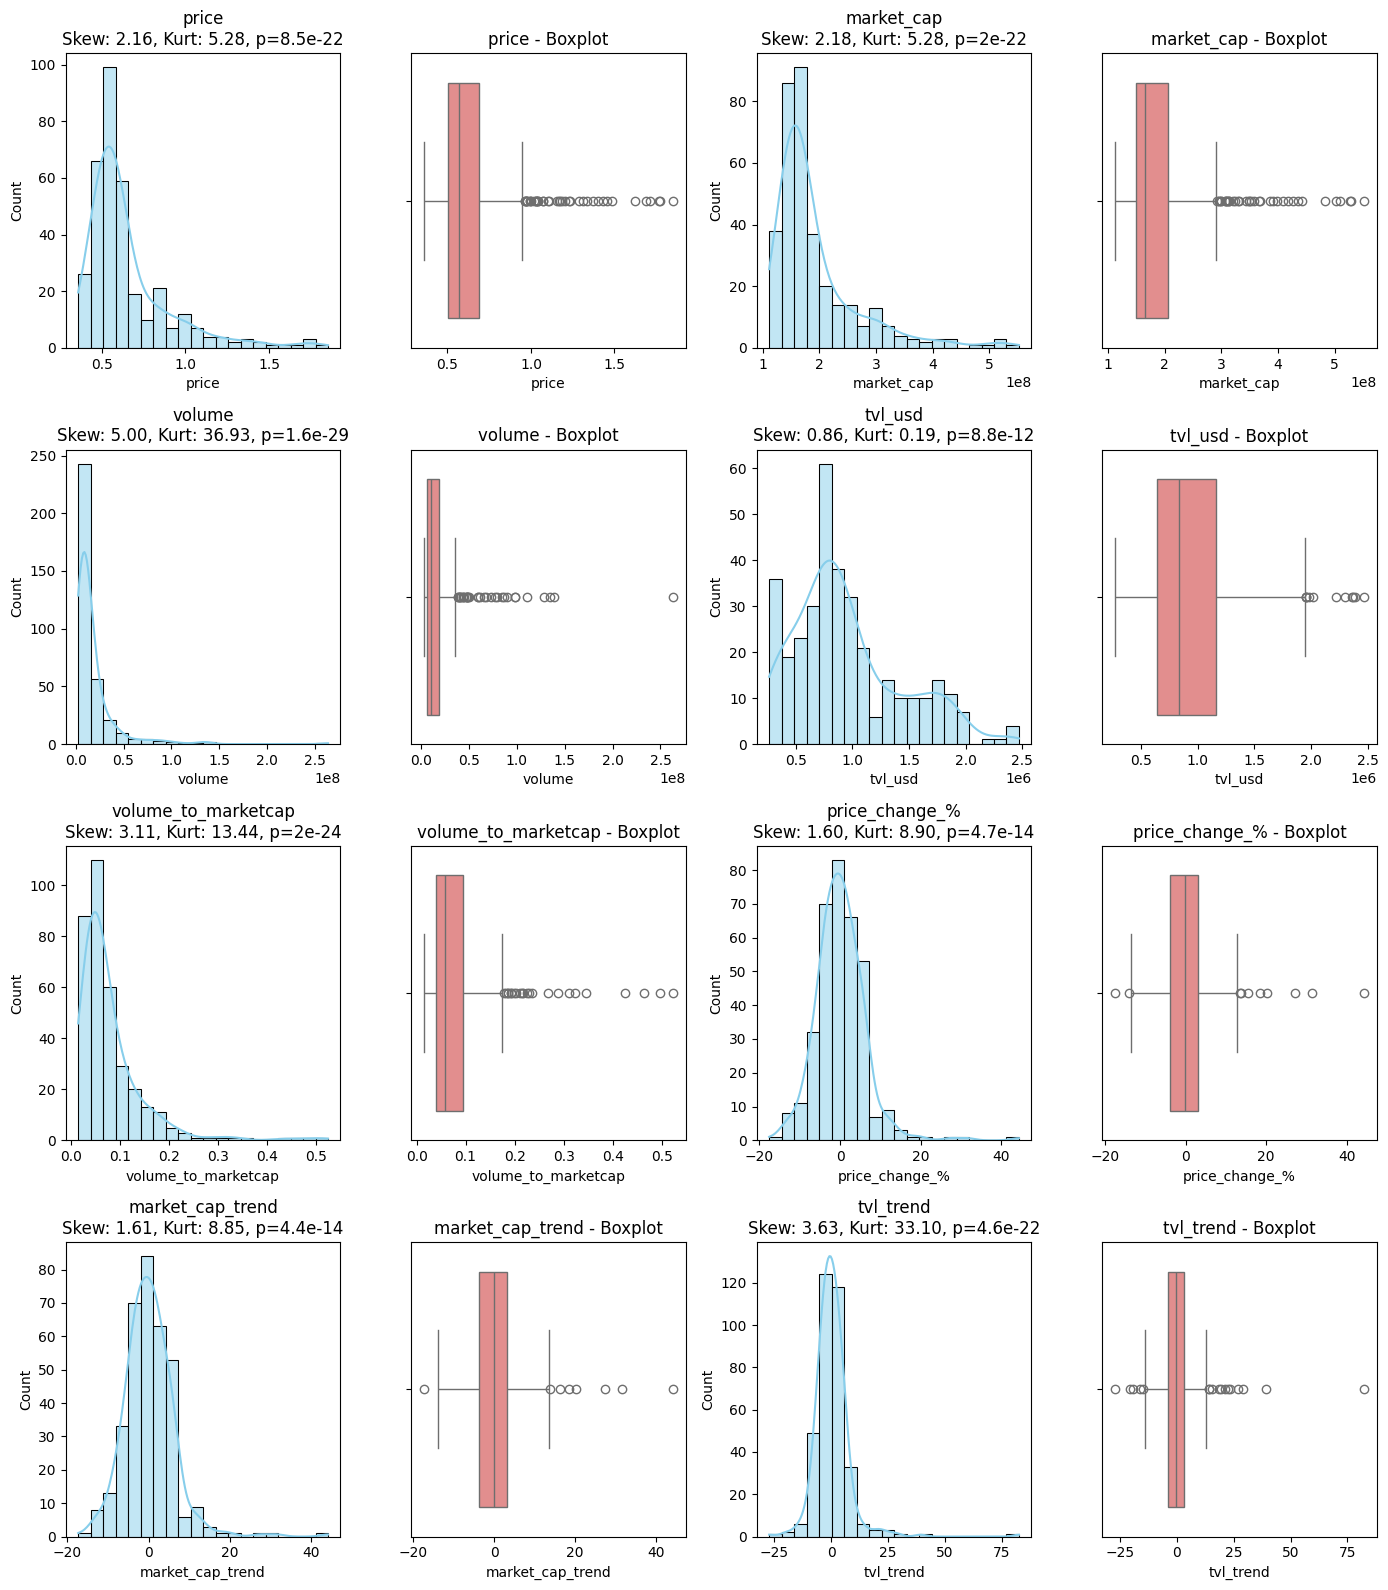

### Distribución de variables numéricas para Kava


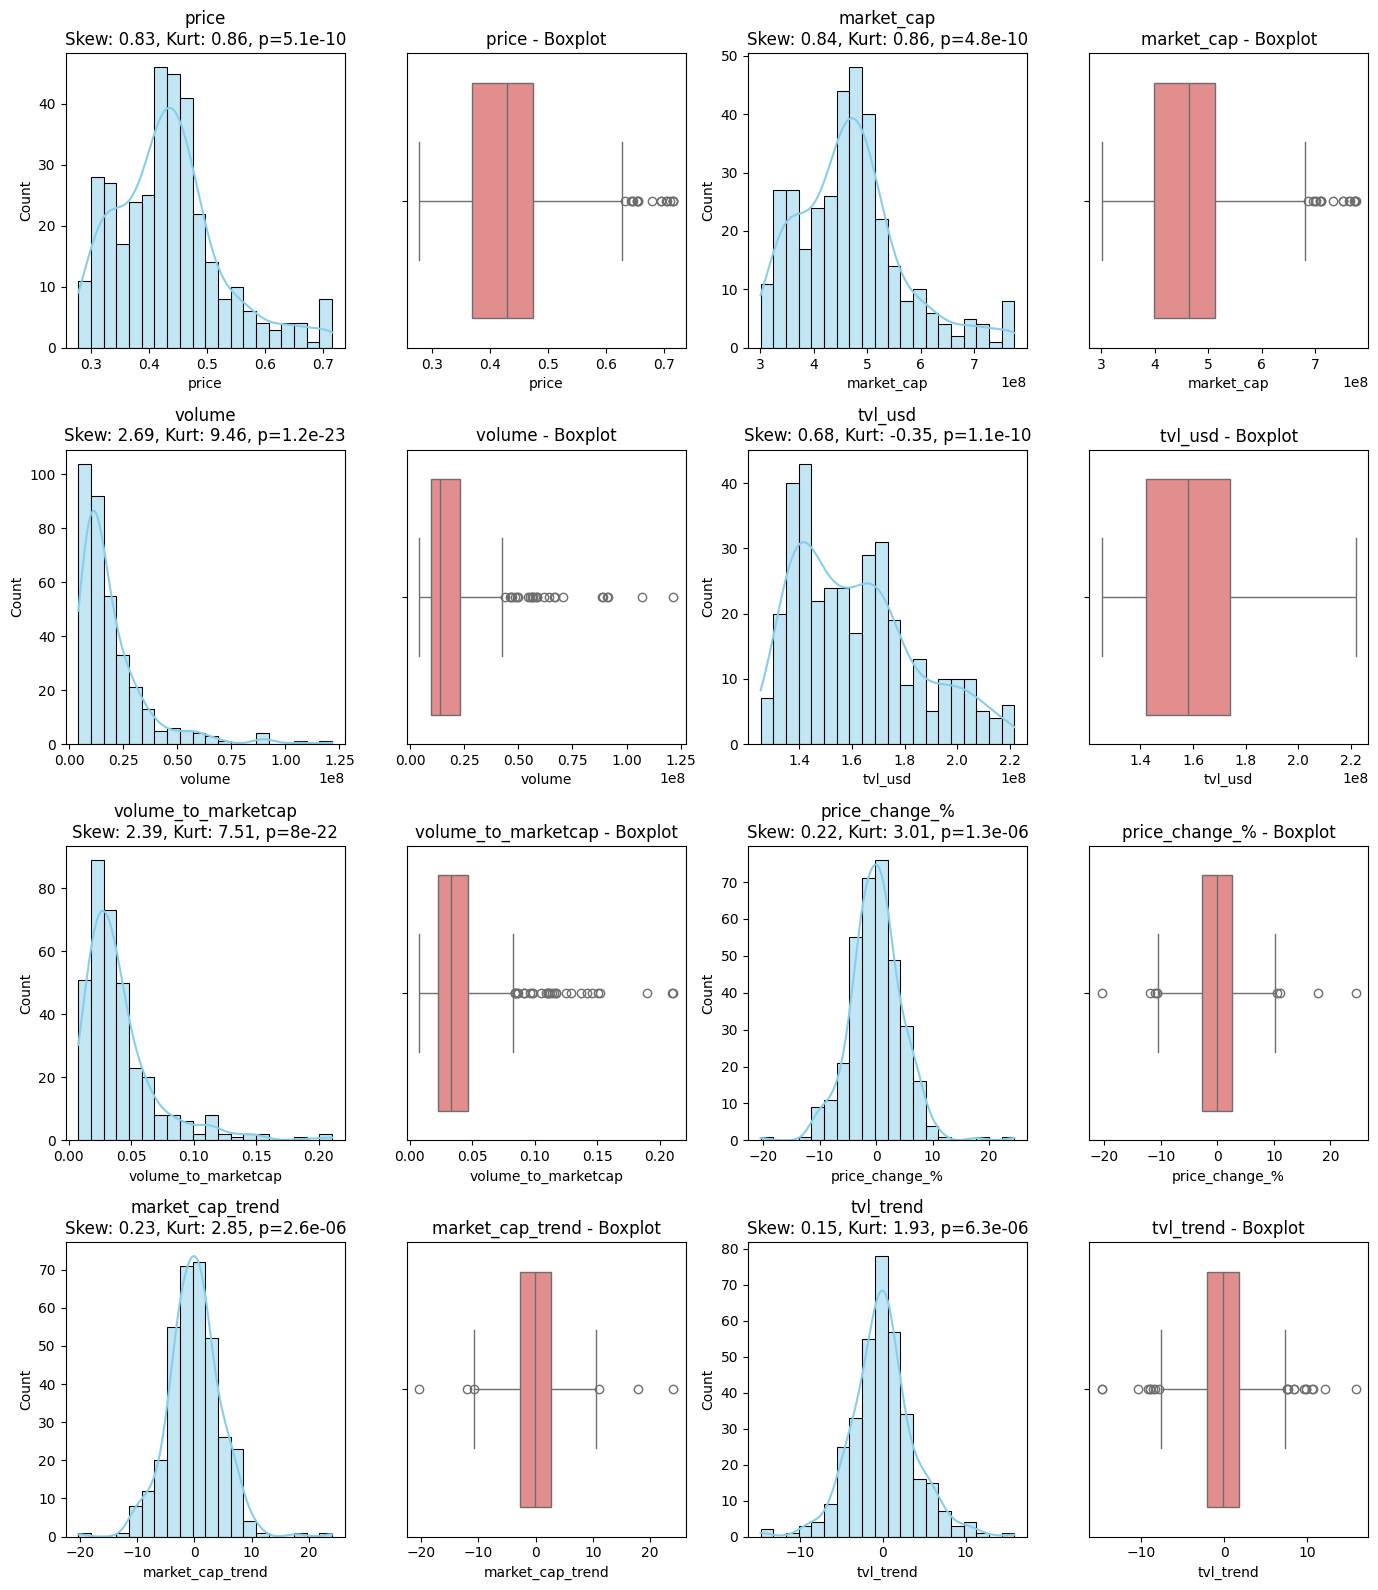

### Distribución de variables numéricas para Nolus


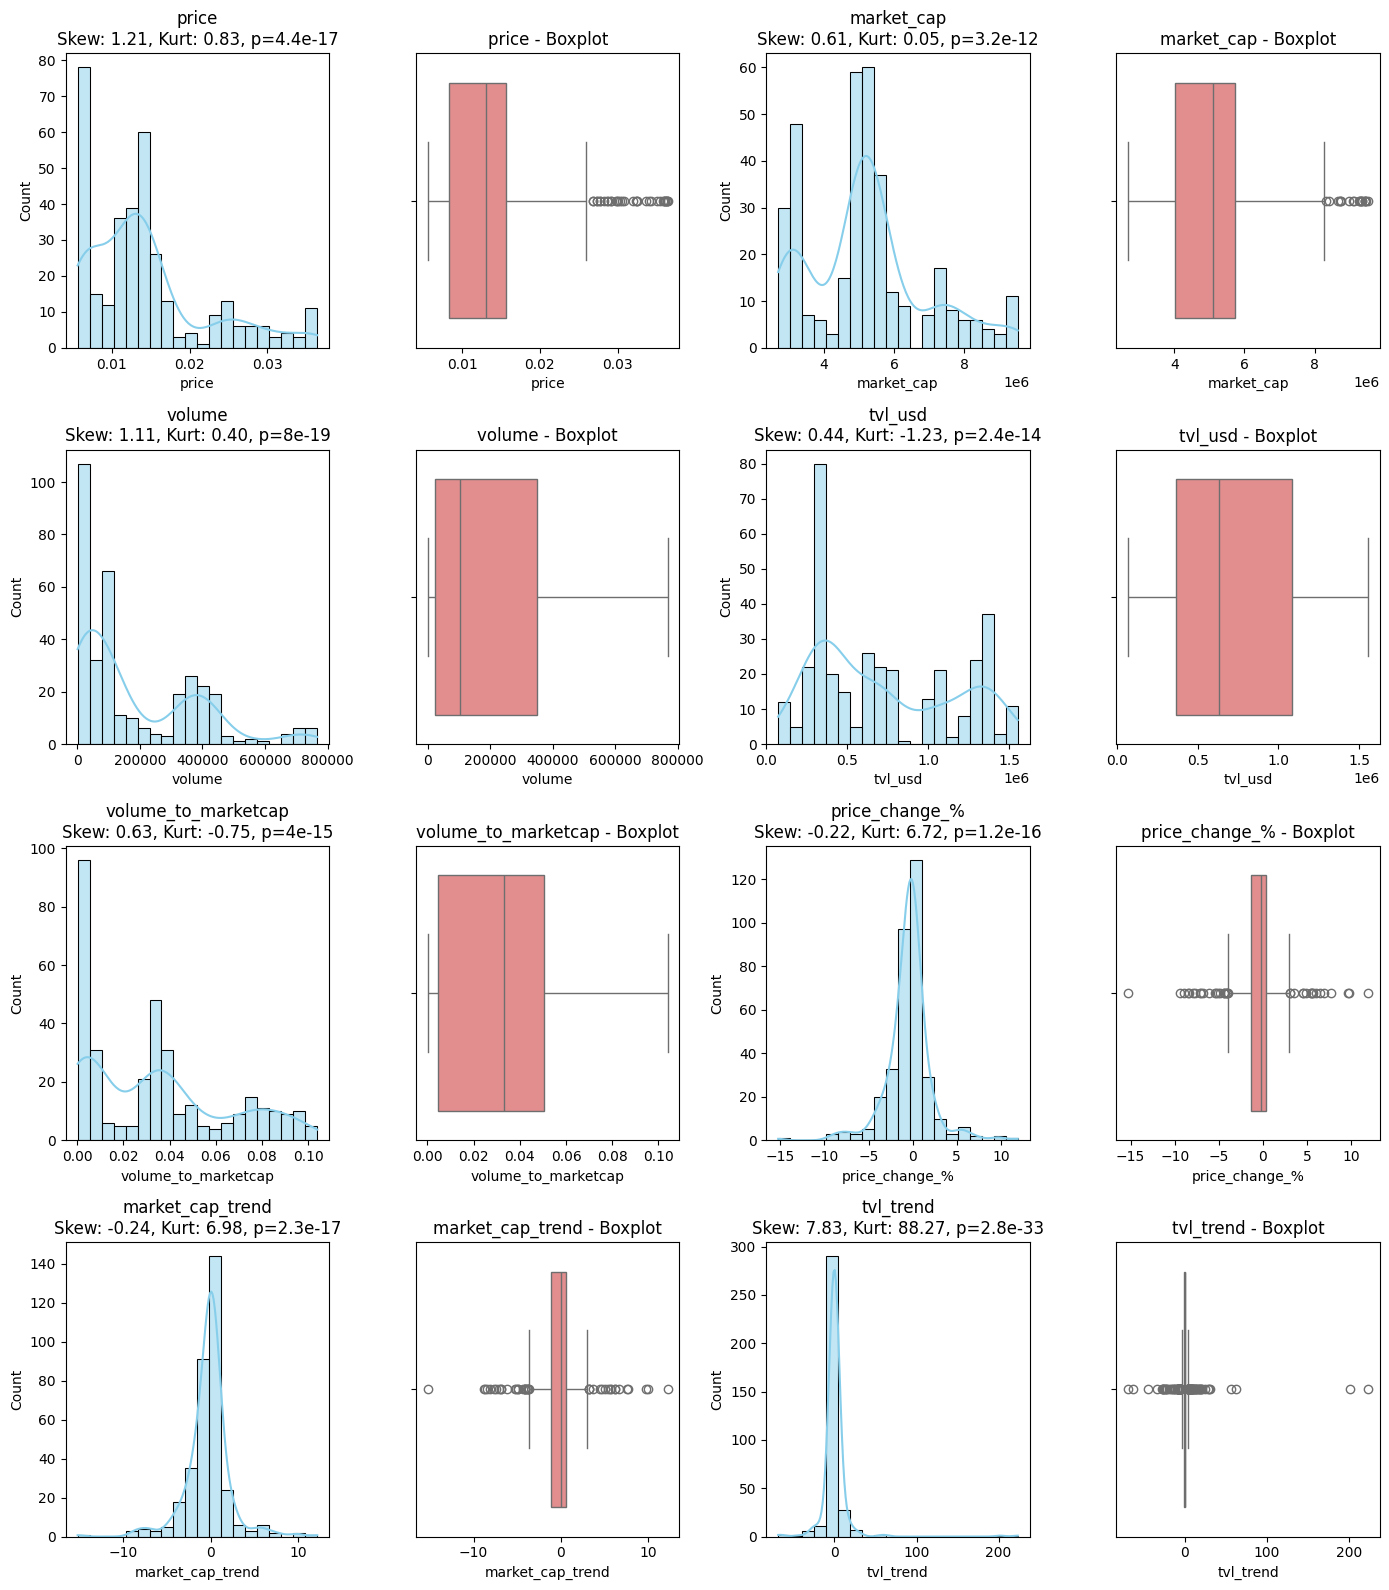

### Distribución de variables numéricas para Stargaze


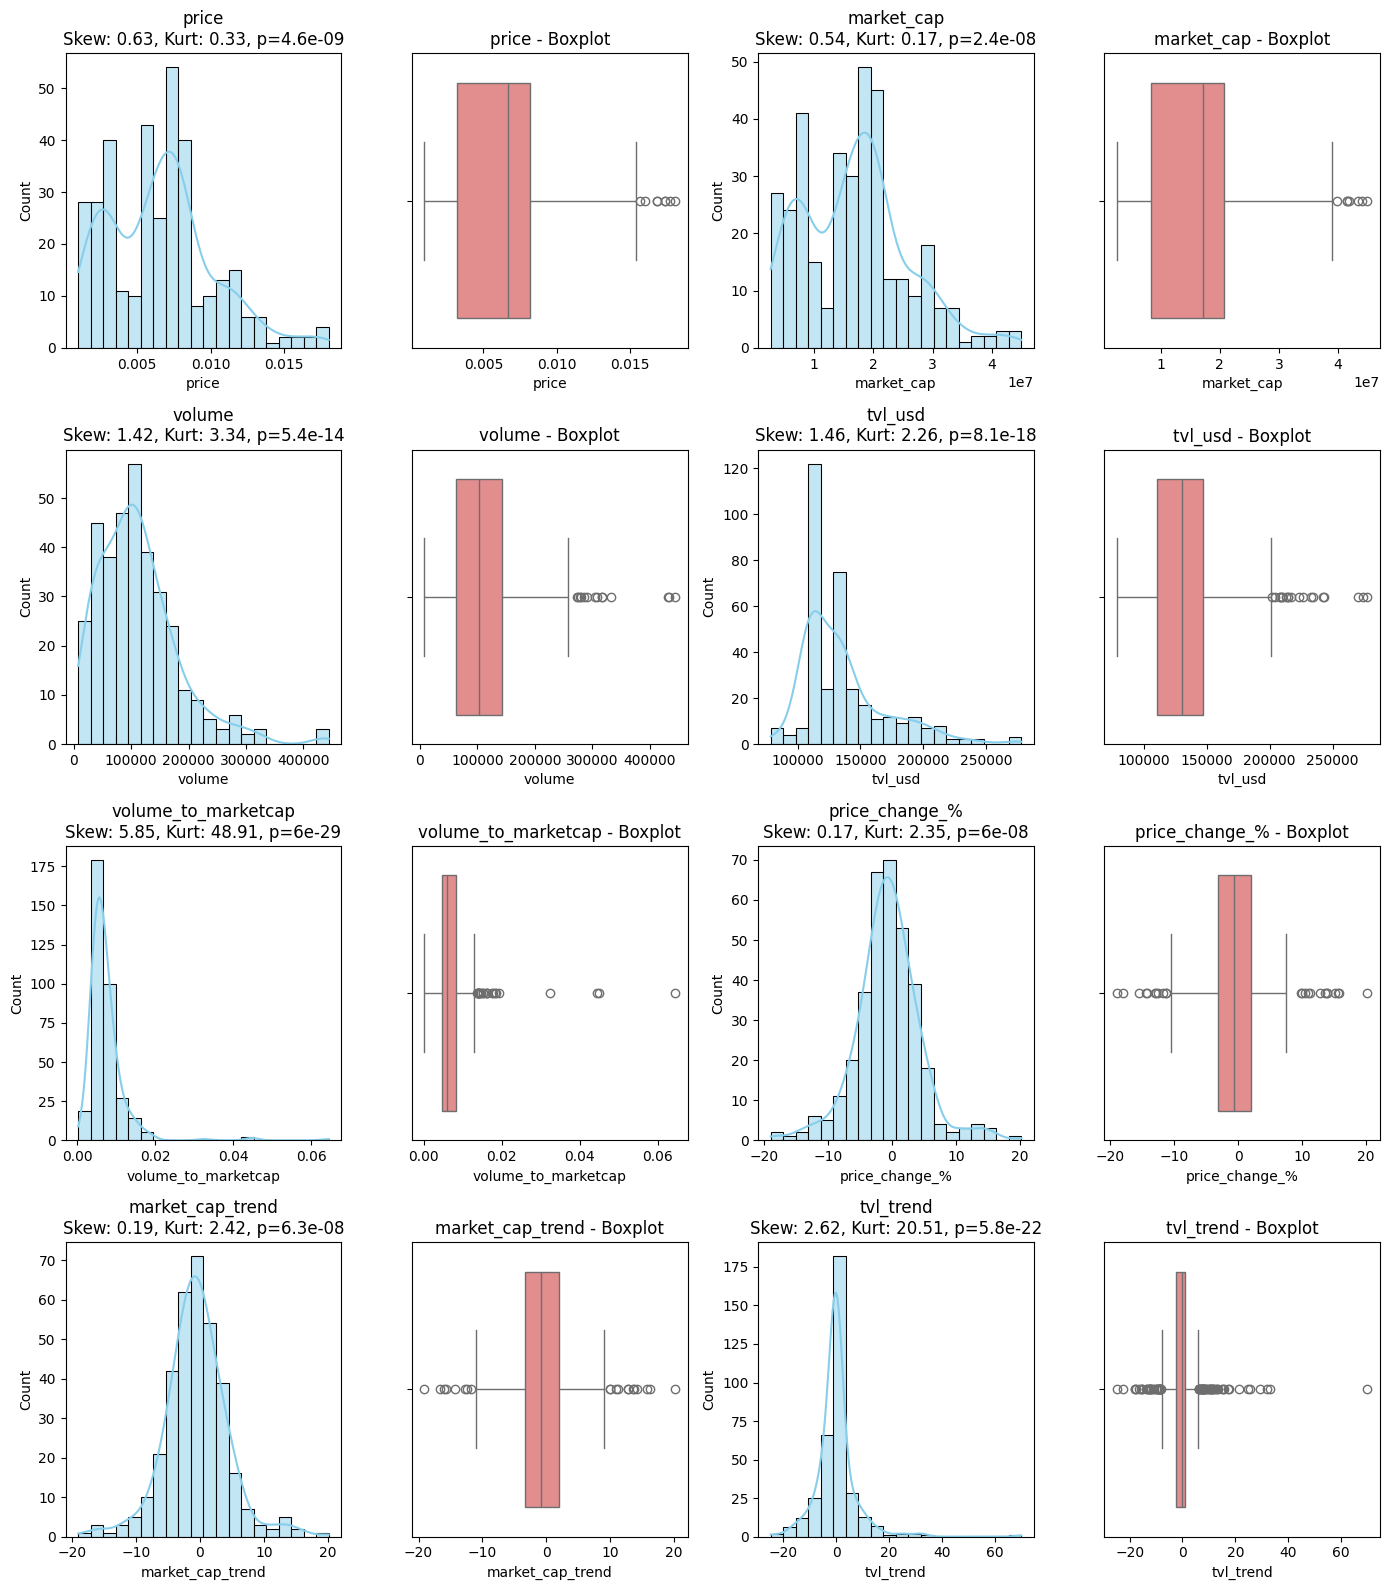

In [24]:
token_name = eda_data["name"].unique()
for token in token_name:
    print(f"### Distribución de variables numéricas para {token}")
    token_data = eda_data[eda_data["name"] == token]
    plot_numeric_distributions(token_data, numeric_columns)


Análisis de la distribución de variables numéticas:

Moneda Harmony:

price: Posee una alta asimetría positiva, una kurtosis medianamente alta, así como un pvalue muchísimos menor a 0.05. Esto lo podemos observar en el histograma puesto a que los bins son mas altos en los valores más bajos y la cola está a la derecha, por otro lado, la concentración es mucho mayor en el extremo izquierdo a comparación del derecho donde la cola es ligera, es por ello que nuestra kurtosis se acerca a 3.

market_cap: ...

Por lo tanto en la fase de preprocesamiento se realizarán transformaciones logarítmicas y suavizado de outliers para contrarestar la asimetría fuerte y las colas pesadas

## Deteccion de outliers estacionales

In [63]:
# Preparación de datos para análisis de outliers estacionales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Convertir columna de fecha y crear variables temporales
eda_data['date'] = pd.to_datetime(eda_data['date'])
eda_data['year'] = eda_data['date'].dt.year
eda_data['month'] = eda_data['date'].dt.month
eda_data['quarter'] = eda_data['date'].dt.quarter

# Información básica del período
print("Información del dataset temporal:")
print(f"Período: {eda_data['date'].min()} a {eda_data['date'].max()}")
print(f"Duración: {(eda_data['date'].max() - eda_data['date'].min()).days} días")
print(f"Años únicos: {sorted(eda_data['year'].unique())}")
print(f"Trimestres únicos: {sorted(eda_data['quarter'].unique())}")
print(f"Total de registros: {len(eda_data)}")

# Variables numéricas a analizar
numeric_columns = eda_data.select_dtypes(include='number').columns
print(f"\nVariables numéricas disponibles: {list(numeric_columns)}")

Información del dataset temporal:
Período: 2024-06-01 00:00:00 a 2025-05-14 00:00:00
Duración: 347 días
Años únicos: [np.int32(2024), np.int32(2025)]
Trimestres únicos: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Total de registros: 1740

Variables numéricas disponibles: ['price', 'market_cap', 'volume', 'tvl_usd', 'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend', 'year', 'month', 'quarter', 'day_of_year', 'week_of_year']


In [64]:
def detectar_outliers_por_periodo(df, columna, agrupacion='quarter', factor_iqr=1.5):
    """
    Detecta outliers agrupando por período temporal (trimestre, mes, etc.)
    
    Parameters:
    - df: DataFrame con los datos
    - columna: nombre de la columna numérica a analizar
    - agrupacion: columna temporal para agrupar ('quarter', 'month')
    - factor_iqr: factor multiplicador para el IQR (1.5 es estándar)
    
    Returns:
    - df_resultado: DataFrame con columna adicional marcando outliers
    - estadisticas: DataFrame con estadísticas por período
    """
    
    df_resultado = df.copy()
    columna_outlier = f'{columna}_outlier_{agrupacion}'
    df_resultado[columna_outlier] = False
    
    estadisticas = []
    
    for periodo in sorted(df[agrupacion].unique()):
        # Filtrar datos del período
        mask_periodo = df[agrupacion] == periodo
        datos_periodo = df[mask_periodo][columna].dropna()
        
        if len(datos_periodo) < 4:
            continue
        
        # Calcular IQR para este período
        q1 = datos_periodo.quantile(0.25)
        q3 = datos_periodo.quantile(0.75)
        iqr = q3 - q1
        
        limite_inferior = q1 - factor_iqr * iqr
        limite_superior = q3 + factor_iqr * iqr
        
        # Marcar outliers
        mask_outliers = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
        df_resultado.loc[mask_periodo & mask_outliers, columna_outlier] = True
        
        # Estadísticas del período
        outliers_count = sum(mask_periodo & mask_outliers)
        total_count = sum(mask_periodo)
        
        estadisticas.append({
            'periodo': periodo,
            'total_observaciones': total_count,
            'outliers': outliers_count,
            'porcentaje_outliers': (outliers_count / total_count * 100) if total_count > 0 else 0,
            'q1': q1,
            'mediana': datos_periodo.median(),
            'q3': q3,
            'iqr': iqr,
            'limite_inferior': limite_inferior,
            'limite_superior': limite_superior
        })
    
    estadisticas_df = pd.DataFrame(estadisticas)
    
    return df_resultado, estadisticas_df

In [65]:
def detectar_outliers_globales(df, columna, factor_iqr=1.5):
    """
    Detecta outliers usando IQR sobre toda la serie sin considerar períodos
    
    Parameters:
    - df: DataFrame con los datos
    - columna: nombre de la columna numérica a analizar
    - factor_iqr: factor multiplicador para el IQR
    
    Returns:
    - df_resultado: DataFrame con columna adicional marcando outliers
    - estadisticas: diccionario con estadísticas globales
    """
    
    df_resultado = df.copy()
    columna_outlier = f'{columna}_outlier_global'
    
    # Calcular IQR global
    datos = df[columna].dropna()
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    
    limite_inferior = q1 - factor_iqr * iqr
    limite_superior = q3 + factor_iqr * iqr
    
    # Marcar outliers
    mask_outliers = (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    df_resultado[columna_outlier] = mask_outliers
    
    # Estadísticas globales
    outliers_count = mask_outliers.sum()
    total_count = len(datos)
    
    estadisticas = {
        'total_observaciones': total_count,
        'outliers': outliers_count,
        'porcentaje_outliers': (outliers_count / total_count * 100) if total_count > 0 else 0,
        'q1': q1,
        'mediana': datos.median(),
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    }
    
    return df_resultado, estadisticas

In [66]:
def test_estacionalidad(df, columna, agrupacion='quarter'):
    """
    Realiza test de chi-cuadrado para determinar si hay dependencia 
    entre el período temporal y la presencia de outliers
    
    Parameters:
    - df: DataFrame con outliers ya detectados
    - columna: nombre de la columna analizada
    - agrupacion: tipo de agrupación temporal
    
    Returns:
    - resultado_test: diccionario con resultados del test
    - tabla_contingencia: tabla cruzada de períodos vs outliers
    """
    
    columna_outlier = f'{columna}_outlier_{agrupacion}'
    
    # Verificar que existe la columna de outliers
    if columna_outlier not in df.columns:
        raise ValueError(f"La columna {columna_outlier} no existe. Ejecute primero la detección de outliers.")
    
    # Crear tabla de contingencia
    tabla_contingencia = pd.crosstab(df[agrupacion], df[columna_outlier], margins=True)
    
    # Test de chi-cuadrado (excluyendo totales)
    tabla_test = tabla_contingencia.iloc[:-1, :-1]
    
    try:
        chi2, p_value, dof, expected = chi2_contingency(tabla_test)
        
        # Calcular coeficiente de variación de proporciones
        proporciones_por_periodo = df.groupby(agrupacion)[columna_outlier].mean()
        cv_proporciones = proporciones_por_periodo.std() / proporciones_por_periodo.mean() if proporciones_por_periodo.mean() > 0 else 0
        
        resultado_test = {
            'chi2': chi2,
            'p_value': p_value,
            'grados_libertad': dof,
            'significativo': p_value < 0.05,
            'cv_proporciones': cv_proporciones,
            'estacionalidad_fuerte': cv_proporciones > 0.3,
            'interpretacion': 'HAY ESTACIONALIDAD' if p_value < 0.05 and cv_proporciones > 0.3 else 'NO HAY ESTACIONALIDAD CLARA'
        }
        
    except Exception as e:
        resultado_test = {
            'error': str(e),
            'interpretacion': 'ERROR EN TEST'
        }
    
    return resultado_test, tabla_contingencia

### Criterios de Significancia para Estacionalidad de Outliers

Para determinar si existe **estacionalidad significativa** en los outliers, se utilizan **dos criterios combinados**:

#### 1. **Significancia Estadística (Test Chi-cuadrado)**
- **Hipótesis nula (H₀)**: No hay relación entre el trimestre y la presencia de outliers
- **Hipótesis alternativa (H₁)**: Existe dependencia entre el trimestre y la presencia de outliers
- **Criterio**: **p-value < 0.05** (nivel de confianza del 95%)
- **Interpretación**: Si p < 0.05, rechazamos H₀ y concluimos que hay dependencia estadísticamente significativa

#### 2. **Magnitud del Efecto (Coeficiente de Variación)**
- **Cálculo**: CV = (desviación estándar / media) de las proporciones de outliers por trimestre
- **Criterio**: **CV > 0.3** (30% de variabilidad relativa)
- **Interpretación**:
  - CV ≤ 0.15: Variabilidad baja (distribución uniforme)
  - 0.15 < CV ≤ 0.3: Variabilidad moderada
  - CV > 0.3: **Variabilidad alta (estacionalidad fuerte)**

#### 3. **Criterio de Decisión Final**
```
HAY ESTACIONALIDAD ⟺ (p-value < 0.05) AND (CV > 0.3)
```

**Justificación**: Se requieren ambos criterios para evitar:
- **Falsos positivos**: Significancia estadística sin relevancia práctica
- **Conclusiones prematuras**: Diferencias pequeñas que son estadísticamente detectables pero no operativamente importantes

**Ejemplo de interpretación**:
- p = 0.001, CV = 0.45 → **HAY ESTACIONALIDAD** (significativo y magnitud alta)
- p = 0.03, CV = 0.12 → **NO HAY ESTACIONALIDAD** (significativo pero magnitud baja)
- p = 0.15, CV = 0.55 → **NO HAY ESTACIONALIDAD** (magnitud alta pero no significativo)

In [70]:
# Análisis completo de estacionalidad de outliers
# Variables numéricas a analizar (excluyendo las de tiempo)
variables_analizar = [col for col in numeric_columns if col not in ['year', 'month', 'quarter']]

print("=== ANÁLISIS DE ESTACIONALIDAD DE OUTLIERS ===\n")
print(f"Variables a analizar: {variables_analizar}\n")

# Diccionario para almacenar todos los resultados
resultados_completos = {}

for variable in variables_analizar:
    print(f"\n{'='*60}")
    print(f"ANÁLISIS DE VARIABLE: {variable.upper()}")
    print(f"{'='*60}")
    
    # 1. Detección de outliers por trimestre
    print("\n1. DETECCIÓN DE OUTLIERS POR TRIMESTRE")
    print("-" * 45)
    
    df_outliers_trimestre, stats_trimestre = detectar_outliers_por_periodo(
        eda_data, variable, agrupacion='quarter'
    )
    
    print(stats_trimestre.round(3))
    
    # 2. Detección de outliers globales
    print("\n2. DETECCIÓN DE OUTLIERS GLOBALES")
    print("-" * 40)
    
    df_outliers_global, stats_global = detectar_outliers_globales(eda_data, variable)
    
    print(f"Total observaciones: {stats_global['total_observaciones']}")
    print(f"Outliers detectados: {stats_global['outliers']}")
    print(f"Porcentaje outliers: {stats_global['porcentaje_outliers']:.2f}%")
    print(f"Límites: [{stats_global['limite_inferior']:.4f}, {stats_global['limite_superior']:.4f}]")
    
    # 3. Test de estacionalidad
    print("\n3. TEST DE ESTACIONALIDAD")
    print("-" * 30)
    
    resultado_test, tabla_contingencia = test_estacionalidad(
        df_outliers_trimestre, variable, agrupacion='quarter'
    )
    
    print("Tabla de contingencia (Trimestre vs Outliers):")
    print(tabla_contingencia)
    print()
    
    if 'error' not in resultado_test:
        print(f"Chi-cuadrado: {resultado_test['chi2']:.4f}")
        print(f"P-value: {resultado_test['p_value']:.6f}")
        print(f"Coeficiente de variación: {resultado_test['cv_proporciones']:.4f}")
        print(f"¿Significativo? {resultado_test['significativo']}")
        print(f"¿Estacionalidad fuerte? {resultado_test['estacionalidad_fuerte']}")
        print(f"\nCONCLUSIÓN: {resultado_test['interpretacion']}")
    else:
        print(f"Error en el test: {resultado_test['error']}")
    
    # Guardar resultados
    resultados_completos[variable] = {
        'stats_trimestre': stats_trimestre,
        'stats_global': stats_global,
        'test_estacionalidad': resultado_test,
        'tabla_contingencia': tabla_contingencia
    }

print(f"\n{'='*80}")
print("ANÁLISIS COMPLETADO PARA TODAS LAS VARIABLES")
print(f"{'='*80}")

=== ANÁLISIS DE ESTACIONALIDAD DE OUTLIERS ===

Variables a analizar: ['price', 'market_cap', 'volume', 'tvl_usd', 'volume_to_marketcap', 'price_change_%', 'market_cap_trend', 'tvl_trend', 'day_of_year', 'week_of_year']


ANÁLISIS DE VARIABLE: PRICE

1. DETECCIÓN DE OUTLIERS POR TRIMESTRE
---------------------------------------------
   periodo  total_observaciones  outliers  porcentaje_outliers     q1  \
0        1                  450         0                0.000  0.006   
1        2                  370         0                0.000  0.010   
2        3                  460         0                0.000  0.011   
3        4                  460        16                3.478  0.012   

   mediana     q3    iqr  limite_inferior  limite_superior  
0    0.015  0.472  0.465           -0.692            1.170  
1    0.021  0.451  0.441           -0.651            1.112  
2    0.017  0.395  0.384           -0.564            0.971  
3    0.016  0.493  0.481           -0.709            1


VISUALIZACIONES DEL ANÁLISIS DE ESTACIONALIDAD

--- Visualización para price ---


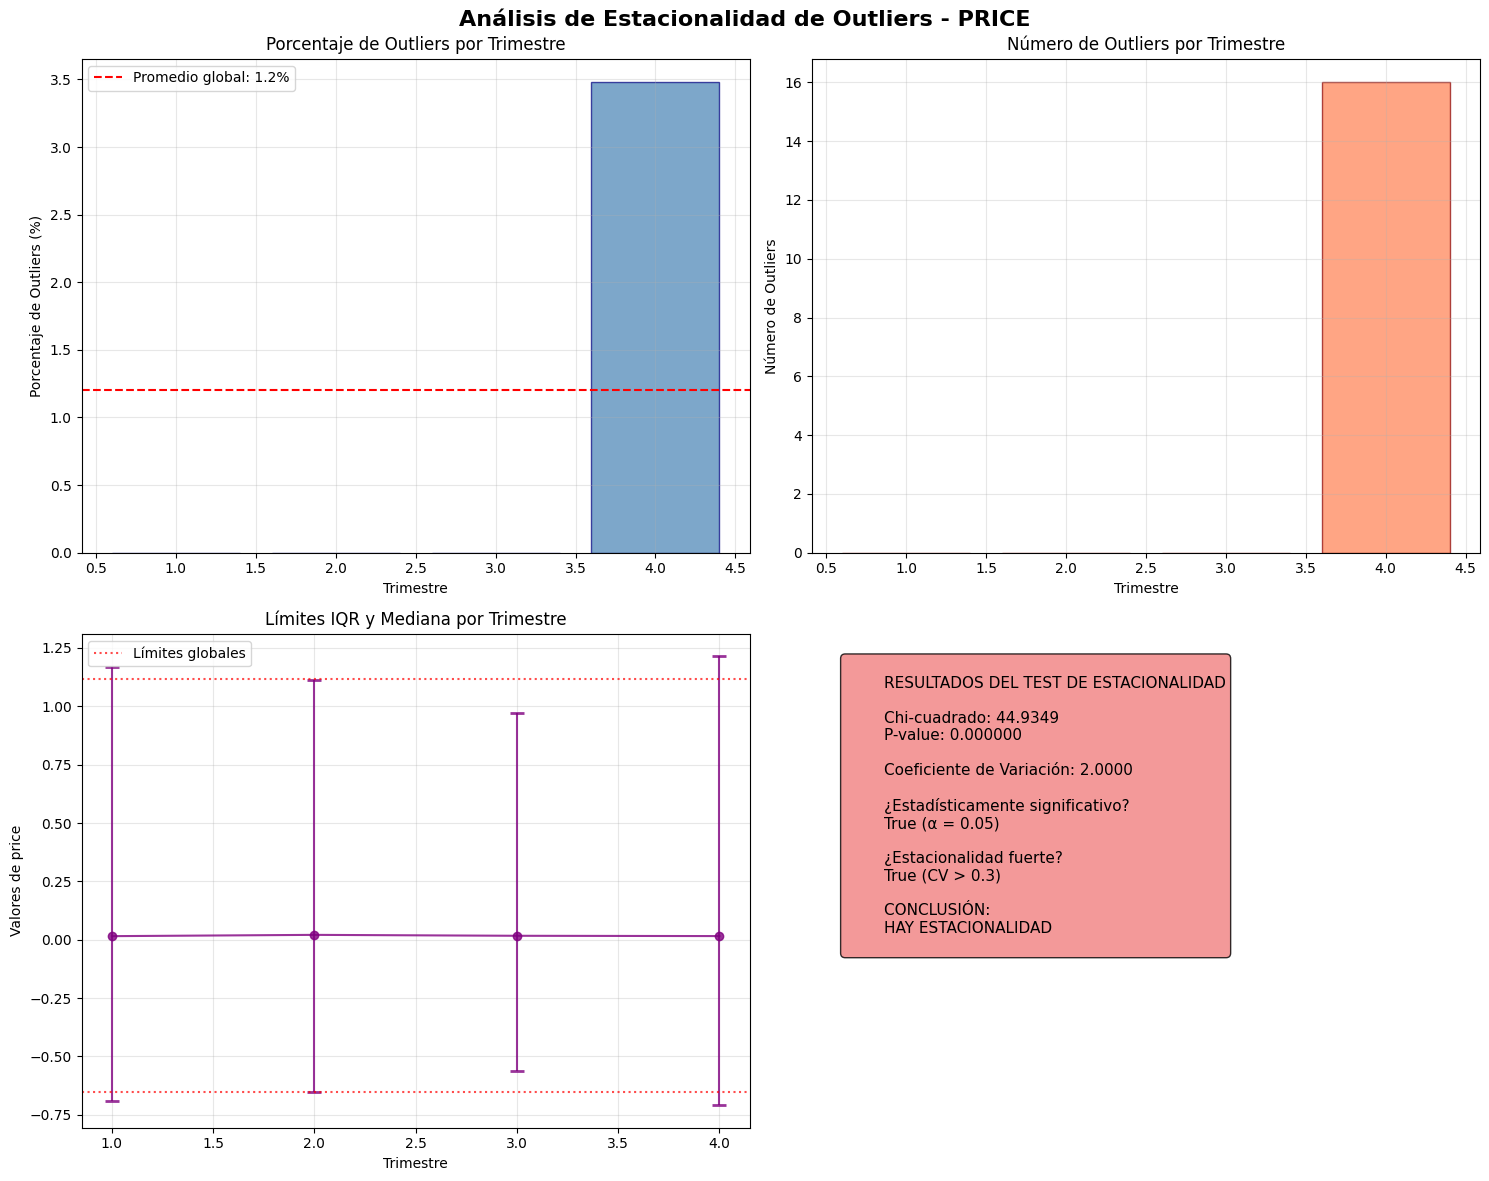


--- Visualización para market_cap ---


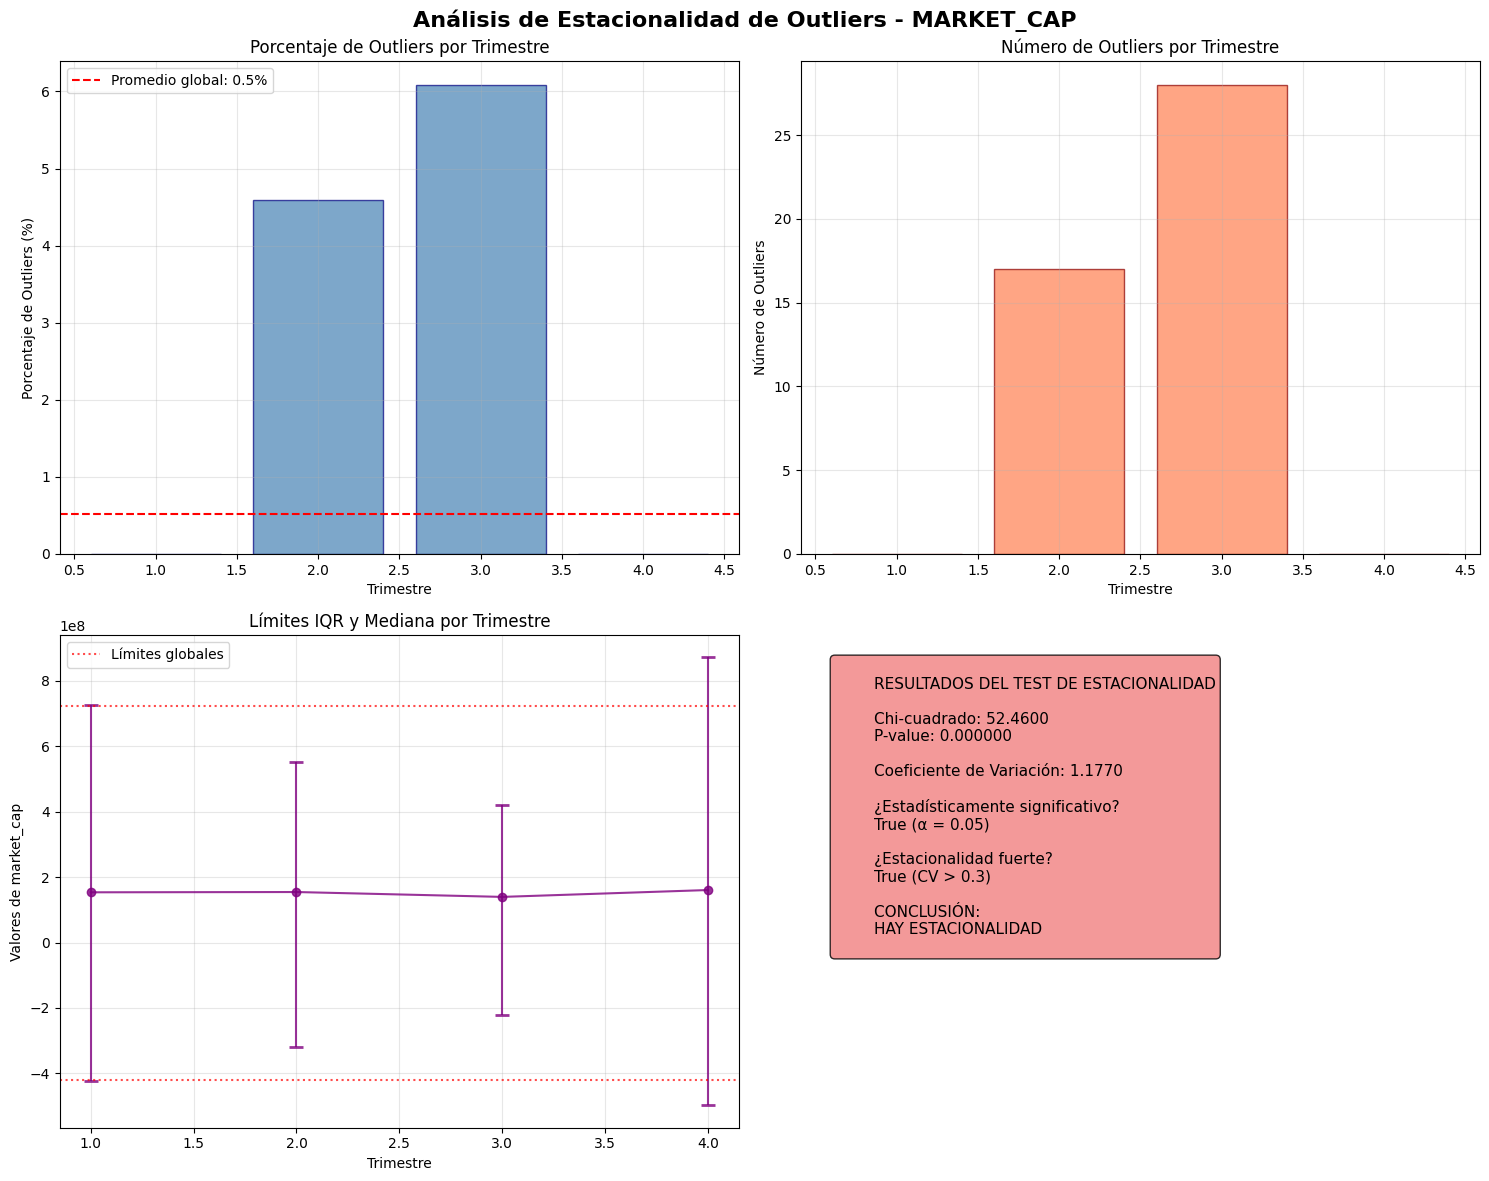


--- Visualización para volume ---


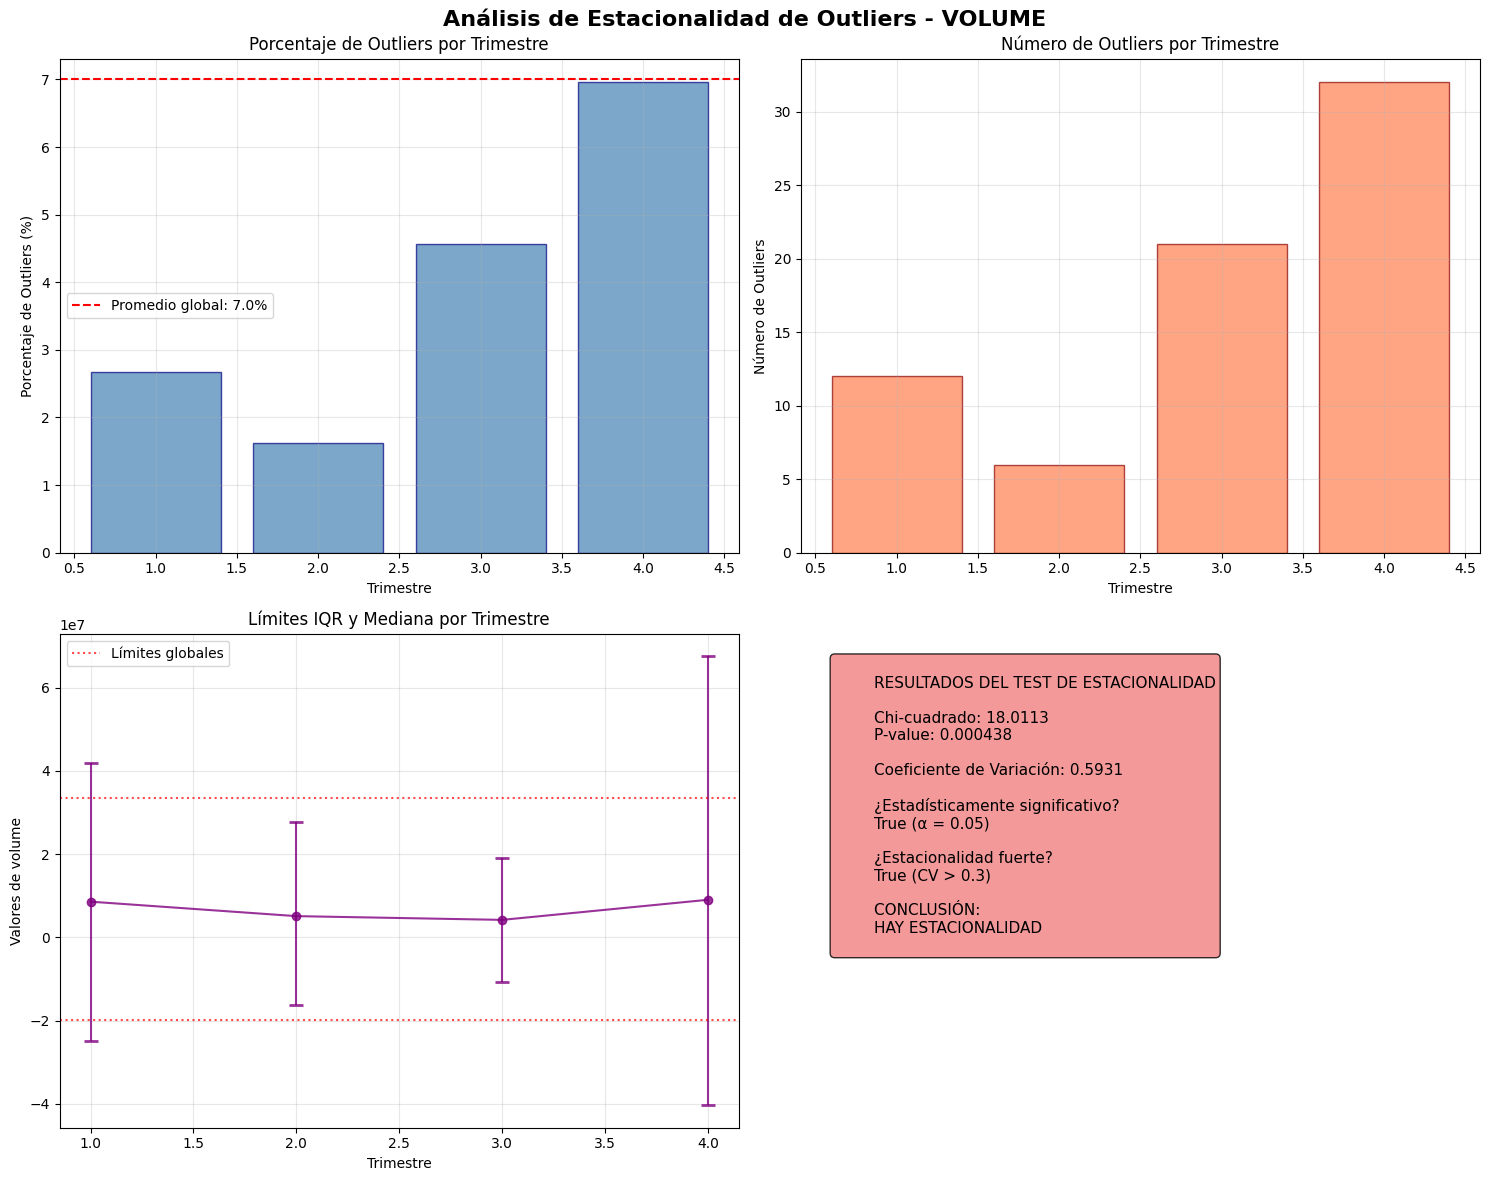


--- Visualización para tvl_usd ---


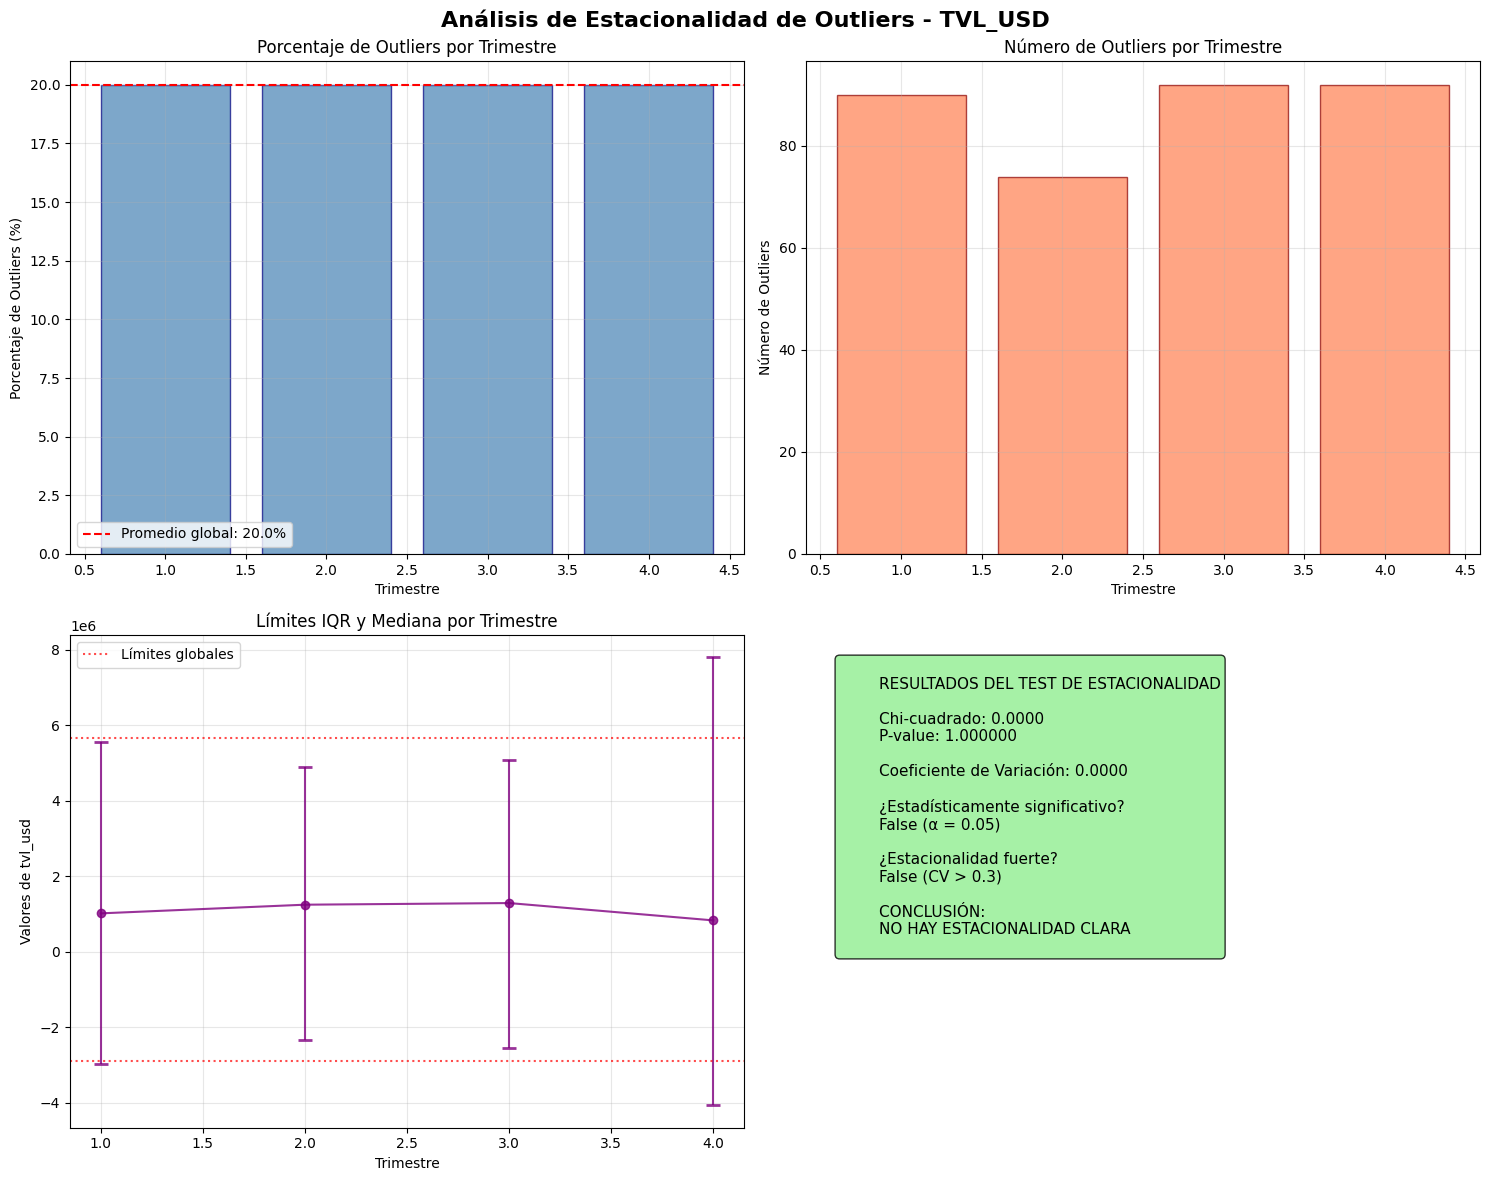


--- Visualización para volume_to_marketcap ---


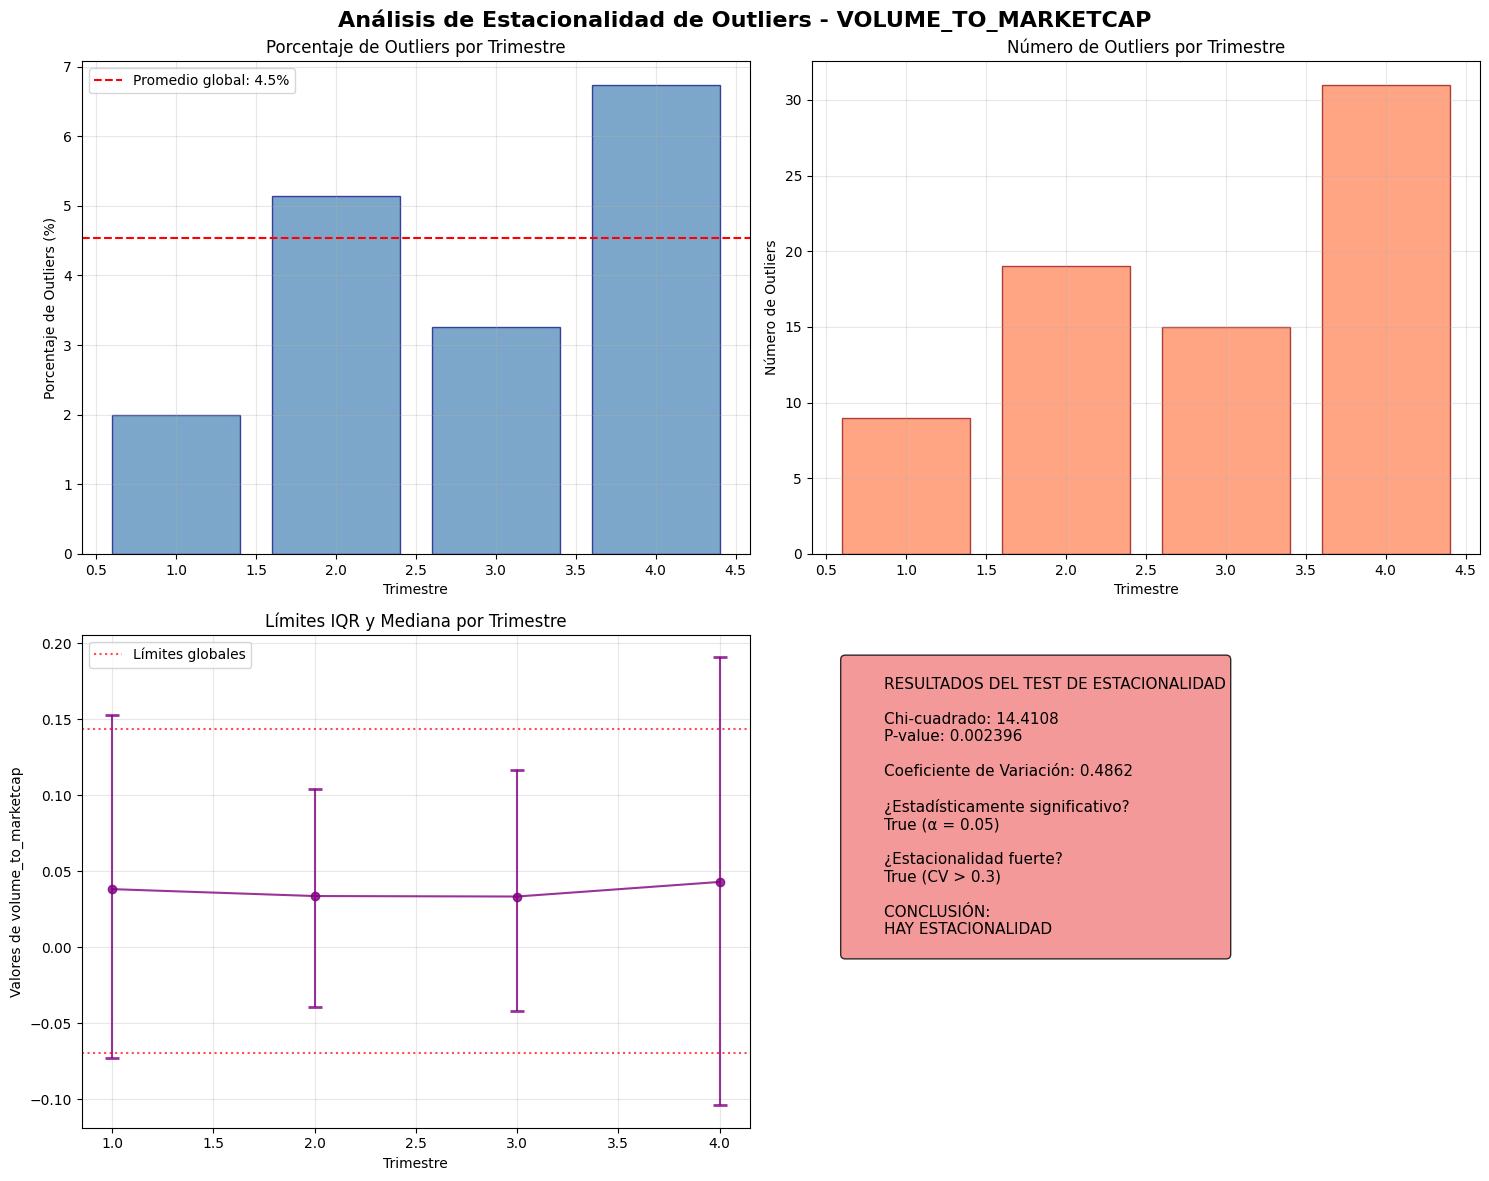


--- Visualización para price_change_% ---


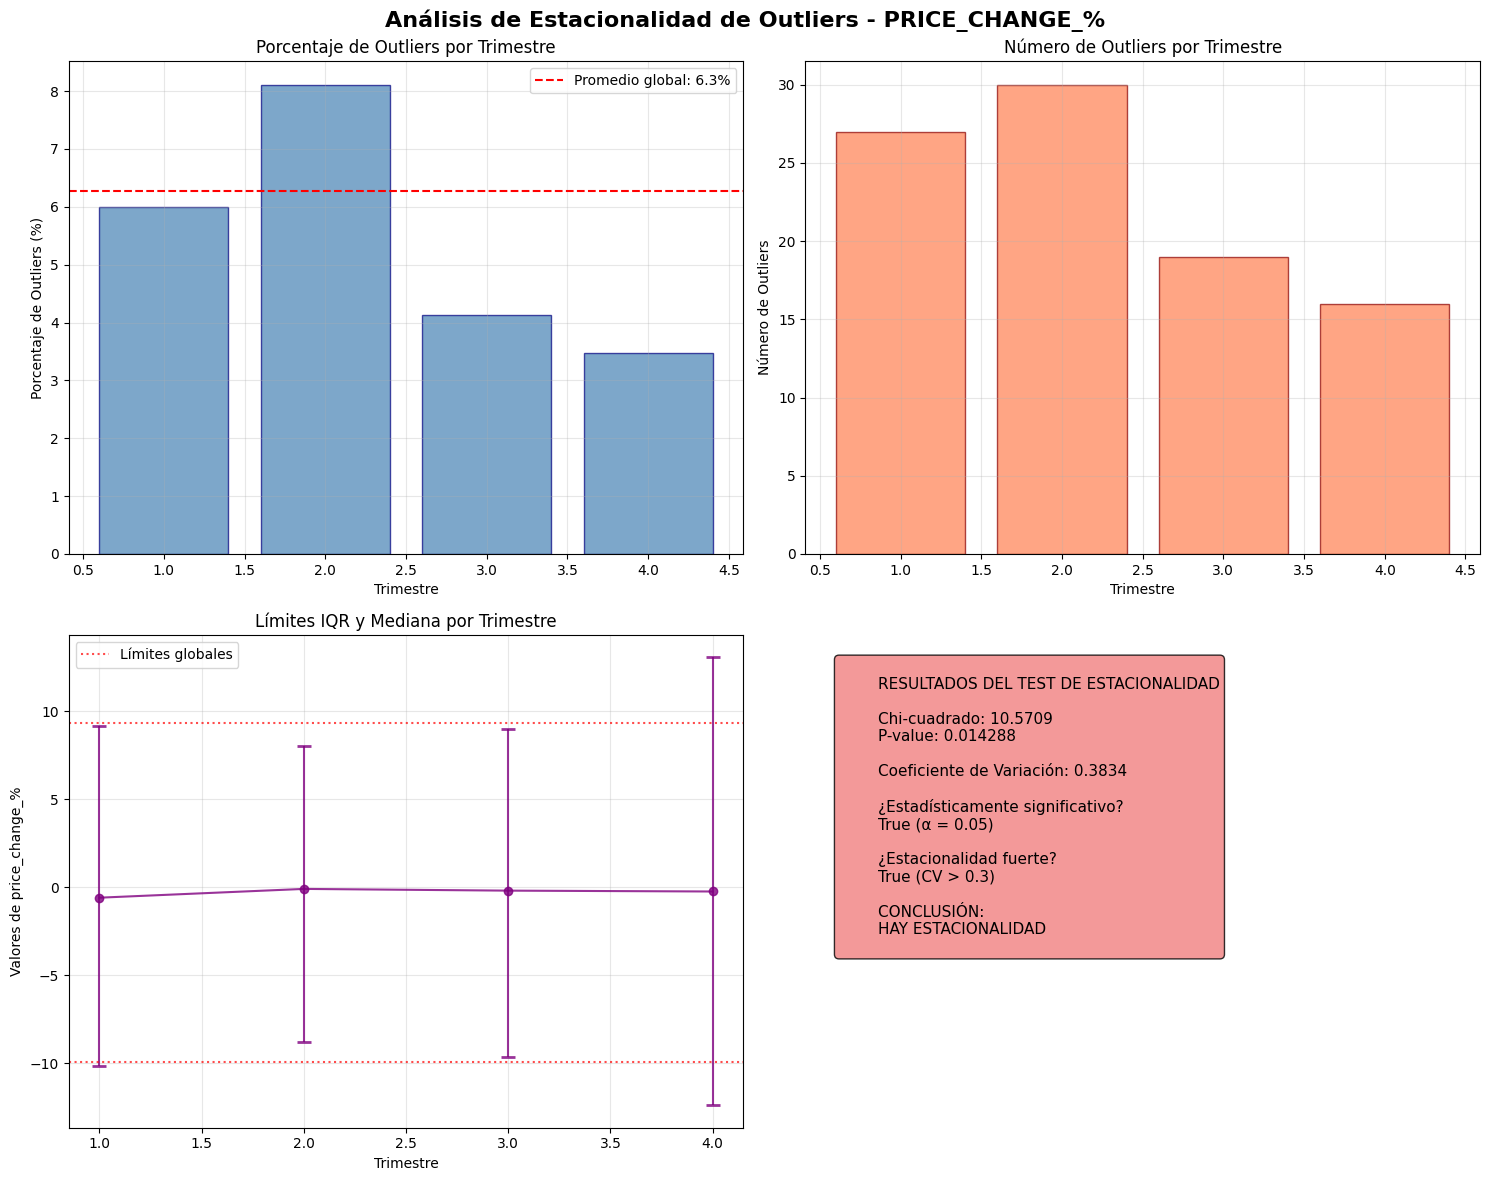


--- Visualización para market_cap_trend ---


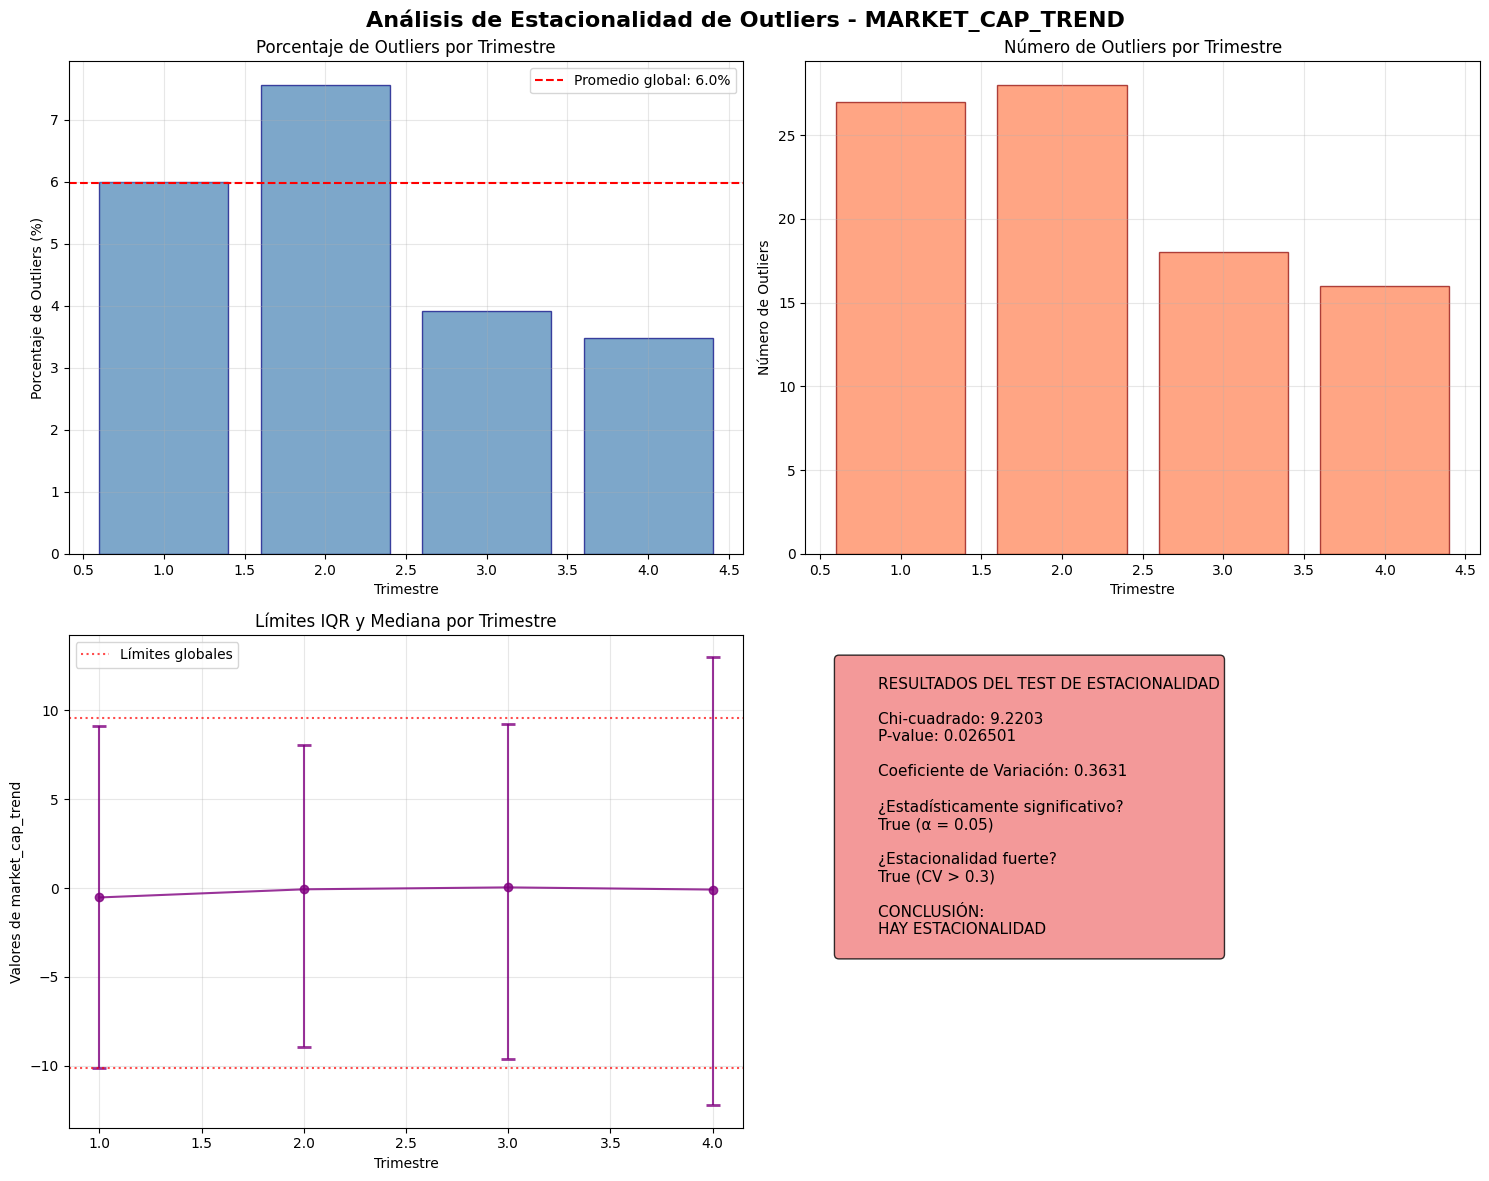


--- Visualización para tvl_trend ---


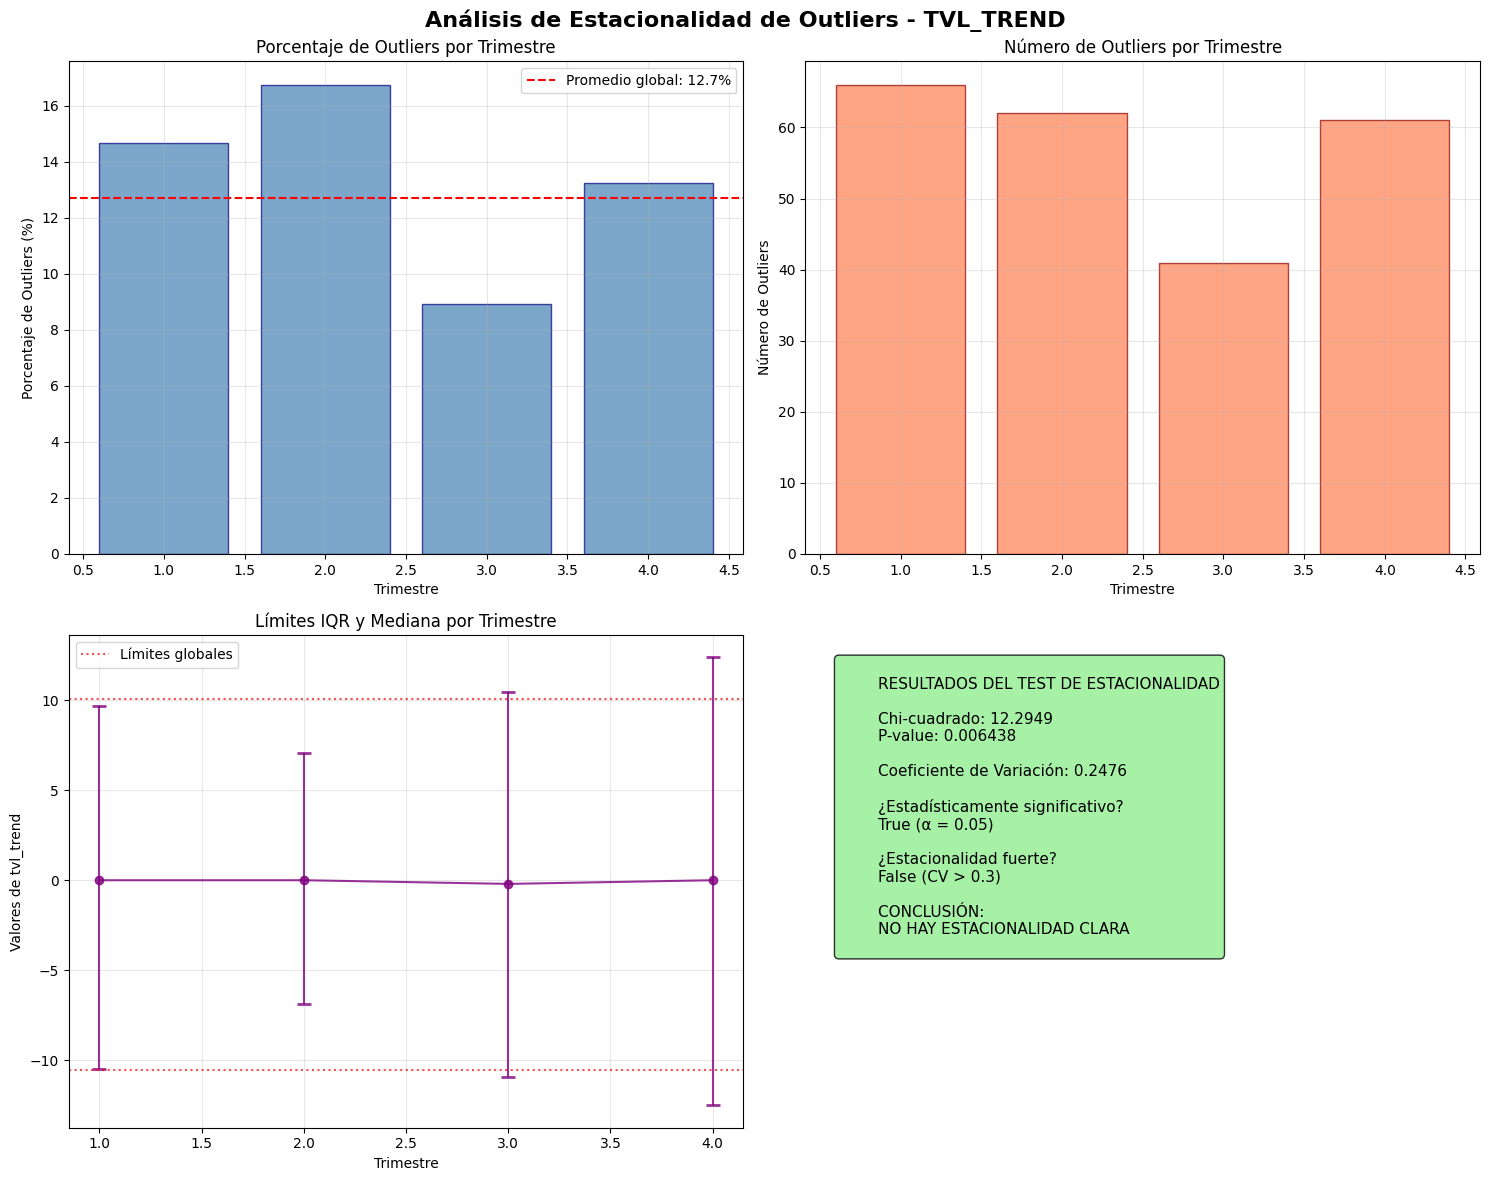


--- Visualización para day_of_year ---


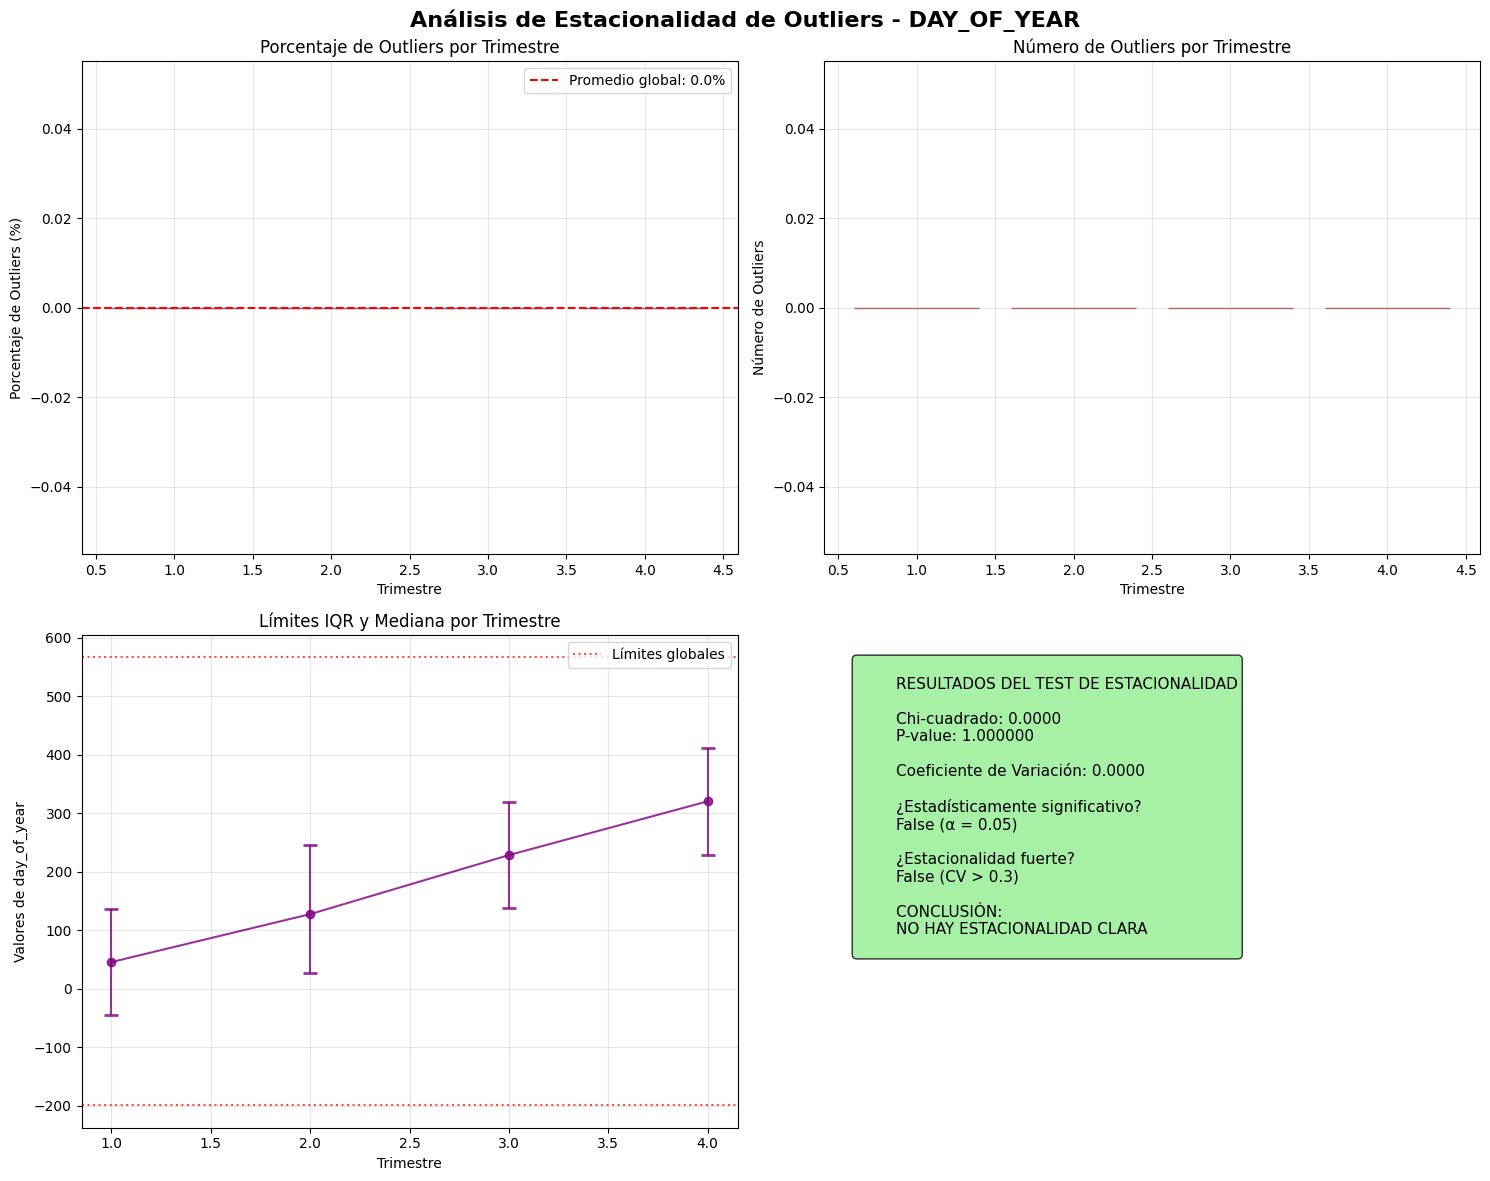


--- Visualización para week_of_year ---


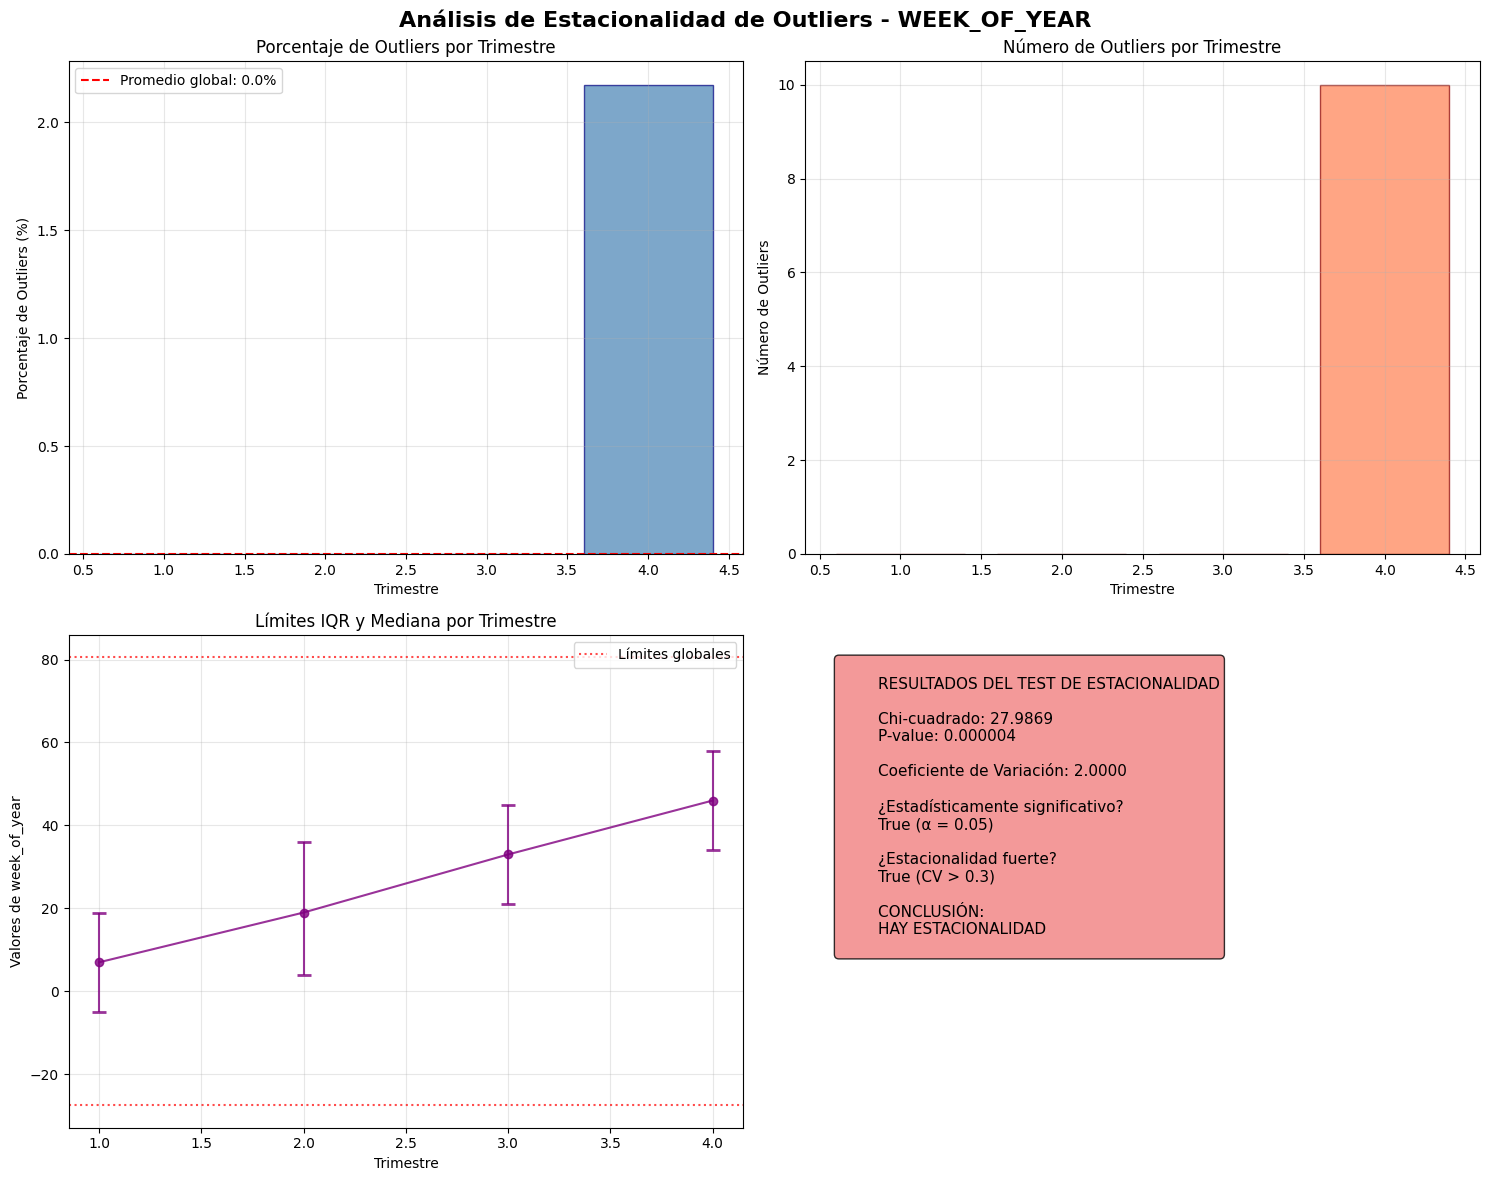

In [68]:
# Visualizaciones del análisis de estacionalidad de outliers

def crear_visualizacion_estacionalidad(variable, resultados):
    """
    Crea visualizaciones completas para el análisis de estacionalidad de una variable
    """
    
    # Obtener datos
    stats_trimestre = resultados['stats_trimestre']
    stats_global = resultados['stats_global']
    test_result = resultados['test_estacionalidad']
    
    # Configurar la figura
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Análisis de Estacionalidad de Outliers - {variable.upper()}', 
                 fontsize=16, fontweight='bold')
    
    # 1. Porcentaje de outliers por trimestre
    ax1.bar(stats_trimestre['periodo'], stats_trimestre['porcentaje_outliers'], 
            color='steelblue', alpha=0.7, edgecolor='navy')
    ax1.set_title('Porcentaje de Outliers por Trimestre')
    ax1.set_xlabel('Trimestre')
    ax1.set_ylabel('Porcentaje de Outliers (%)')
    ax1.grid(True, alpha=0.3)
    
    # Línea horizontal con el promedio global
    promedio_global = stats_global['porcentaje_outliers']
    ax1.axhline(y=promedio_global, color='red', linestyle='--', 
                label=f'Promedio global: {promedio_global:.1f}%')
    ax1.legend()
    
    # 2. Número absoluto de outliers por trimestre
    ax2.bar(stats_trimestre['periodo'], stats_trimestre['outliers'], 
            color='coral', alpha=0.7, edgecolor='darkred')
    ax2.set_title('Número de Outliers por Trimestre')
    ax2.set_xlabel('Trimestre')
    ax2.set_ylabel('Número de Outliers')
    ax2.grid(True, alpha=0.3)
    
    # 3. Comparación de límites IQR por trimestre
    ax3.errorbar(stats_trimestre['periodo'], stats_trimestre['mediana'],
                yerr=[stats_trimestre['mediana'] - stats_trimestre['limite_inferior'],
                      stats_trimestre['limite_superior'] - stats_trimestre['mediana']],
                fmt='o-', capsize=5, capthick=2, color='purple', alpha=0.8)
    ax3.set_title('Límites IQR y Mediana por Trimestre')
    ax3.set_xlabel('Trimestre')
    ax3.set_ylabel(f'Valores de {variable}')
    ax3.grid(True, alpha=0.3)
    
    # Límites globales como referencia
    ax3.axhline(y=stats_global['limite_inferior'], color='red', linestyle=':', 
                alpha=0.7, label='Límites globales')
    ax3.axhline(y=stats_global['limite_superior'], color='red', linestyle=':', alpha=0.7)
    ax3.legend()
    
    # 4. Resumen del test estadístico
    ax4.axis('off')
    
    # Texto del resumen
    if 'error' not in test_result:
        resumen_texto = f"""
        RESULTADOS DEL TEST DE ESTACIONALIDAD
        
        Chi-cuadrado: {test_result['chi2']:.4f}
        P-value: {test_result['p_value']:.6f}
        
        Coeficiente de Variación: {test_result['cv_proporciones']:.4f}
        
        ¿Estadísticamente significativo?
        {test_result['significativo']} (α = 0.05)
        
        ¿Estacionalidad fuerte?
        {test_result['estacionalidad_fuerte']} (CV > 0.3)
        
        CONCLUSIÓN:
        {test_result['interpretacion']}
        """
        
        # Color de fondo según el resultado
        if test_result['interpretacion'] == 'HAY ESTACIONALIDAD':
            color_fondo = 'lightcoral'
        else:
            color_fondo = 'lightgreen'
        
    else:
        resumen_texto = f"ERROR EN TEST: {test_result['error']}"
        color_fondo = 'lightyellow'
    
    ax4.text(0.05, 0.95, resumen_texto, transform=ax4.transAxes, fontsize=11,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor=color_fondo, alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Crear visualizaciones para cada variable
print("\n" + "="*80)
print("VISUALIZACIONES DEL ANÁLISIS DE ESTACIONALIDAD")
print("="*80)

for variable in variables_analizar:
    if variable in resultados_completos:
        print(f"\n--- Visualización para {variable} ---")
        crear_visualizacion_estacionalidad(variable, resultados_completos[variable])

In [69]:
# Resumen final y conclusiones del análisis

print("\n" + "="*100)
print("RESUMEN EJECUTIVO - ANÁLISIS DE ESTACIONALIDAD DE OUTLIERS")
print("="*100)

# Crear tabla resumen
resumen_datos = []

for variable in variables_analizar:
    if variable in resultados_completos:
        resultado = resultados_completos[variable]
        
        # Extraer información clave
        outliers_global = resultado['stats_global']['porcentaje_outliers']
        
        # Variabilidad entre trimestres
        porcentajes_trimestre = resultado['stats_trimestre']['porcentaje_outliers']
        cv_outliers = porcentajes_trimestre.std() / porcentajes_trimestre.mean() if porcentajes_trimestre.mean() > 0 else 0
        
        # Test estadístico
        if 'error' not in resultado['test_estacionalidad']:
            p_value = resultado['test_estacionalidad']['p_value']
            significativo = resultado['test_estacionalidad']['significativo']
            interpretacion = resultado['test_estacionalidad']['interpretacion']
        else:
            p_value = None
            significativo = False
            interpretacion = "ERROR"
        
        resumen_datos.append({
            'Variable': variable,
            'Outliers_Global_%': round(outliers_global, 2),
            'CV_Trimestres': round(cv_outliers, 4),
            'P_value': round(p_value, 6) if p_value is not None else 'N/A',
            'Significativo': significativo,
            'Estacionalidad': interpretacion
        })

# Crear DataFrame resumen
df_resumen = pd.DataFrame(resumen_datos)

print("\nTABLA RESUMEN:")
print("-" * 90)
print(df_resumen.to_string(index=False))

# Análisis por categorías
variables_con_estacionalidad = df_resumen[df_resumen['Estacionalidad'] == 'HAY ESTACIONALIDAD']
variables_sin_estacionalidad = df_resumen[df_resumen['Estacionalidad'] == 'NO HAY ESTACIONALIDAD CLARA']

print(f"\n\nRESULTADOS PRINCIPALES:")
print("-" * 50)
print(f"Total de variables analizadas: {len(df_resumen)}")
print(f"Variables CON estacionalidad de outliers: {len(variables_con_estacionalidad)}")
print(f"Variables SIN estacionalidad clara: {len(variables_sin_estacionalidad)}")

if len(variables_con_estacionalidad) > 0:
    print(f"\nVARIABLES CON ESTACIONALIDAD:")
    for _, row in variables_con_estacionalidad.iterrows():
        print(f"  • {row['Variable']}: {row['Outliers_Global_%']}% outliers globales, CV={row['CV_Trimestres']}")

if len(variables_sin_estacionalidad) > 0:
    print(f"\nVARIABLES SIN ESTACIONALIDAD CLARA:")
    for _, row in variables_sin_estacionalidad.iterrows():
        print(f"  • {row['Variable']}: {row['Outliers_Global_%']}% outliers globales, CV={row['CV_Trimestres']}")

print(f"\n\nINTERPRETACIÓN METODOLÓGICA:")
print("-" * 60)
print("""
1. DETECCIÓN DE OUTLIERS:
   - Se utilizó el método IQR (Rango Intercuartílico) con factor 1.5
   - Análisis por trimestre: Outliers detectados independientemente en cada trimestre
   - Análisis global: Outliers detectados sobre toda la serie temporal

2. TEST DE ESTACIONALIDAD:
   - Chi-cuadrado: Evalúa dependencia entre trimestre y presencia de outliers
   - Coeficiente de Variación: Mide variabilidad de proporciones entre trimestres
   - Criterios: p < 0.05 Y CV > 0.3 para confirmar estacionalidad

3. INTERPRETACIÓN DE RESULTADOS:
   - HAY ESTACIONALIDAD: Los outliers se concentran significativamente en ciertos trimestres
   - NO HAY ESTACIONALIDAD: Los outliers están distribuidos uniformemente en el tiempo
   - Esto tiene implicaciones para modelos predictivos y estrategias de trading
""")

print(f"\n\nRECOMENDACIONES:")
print("-" * 40)

if len(variables_con_estacionalidad) > 0:
    print("VARIABLES CON ESTACIONALIDAD:")
    print("• Considerar modelos específicos por trimestre")
    print("• Implementar estrategias de detección de anomalías adaptativas")
    print("• Ajustar umbrales de alerta según el período del año")
    print("• Investigar factores externos que pueden causar esta estacionalidad")

if len(variables_sin_estacionalidad) > 0:
    print("\nVARIABLES SIN ESTACIONALIDAD:")
    print("• Utilizar modelos globales estables")
    print("• Aplicar umbrales de detección constantes")
    print("• Los outliers pueden ser eventos aleatorios o relacionados con noticias/eventos específicos")

print(f"\n{'='*100}")
print("ANÁLISIS COMPLETADO")
print(f"{'='*100}")


RESUMEN EJECUTIVO - ANÁLISIS DE ESTACIONALIDAD DE OUTLIERS

TABLA RESUMEN:
------------------------------------------------------------------------------------------
           Variable  Outliers_Global_%  CV_Trimestres  P_value  Significativo              Estacionalidad
              price               1.21         2.0000 0.000000           True          HAY ESTACIONALIDAD
         market_cap               0.52         1.1770 0.000000           True          HAY ESTACIONALIDAD
             volume               7.01         0.5931 0.000438           True          HAY ESTACIONALIDAD
            tvl_usd              20.00         0.0000 1.000000          False NO HAY ESTACIONALIDAD CLARA
volume_to_marketcap               4.54         0.4862 0.002396           True          HAY ESTACIONALIDAD
     price_change_%               6.26         0.3834 0.014288           True          HAY ESTACIONALIDAD
   market_cap_trend               5.98         0.3631 0.026501           True          HAY 